Clinical: (110, 22)
RNA: (19293, 185)
Protein: (11355, 185)

Tumour samples: 110

After tumour filtering
RNA: (19293, 111)
Protein: (11355, 111)
Clinical: (110, 22)

Histology distribution
histologic_type
Clear cell renal cell carcinoma        103
non-Clear Cell renal cell carcinoma      7
Name: count, dtype: int64

After ccRCC filtering
RNA: (19293, 104)
Protein: (11355, 104)
Clinical: (103, 22)

Grade distribution
grade_bin
Low     55
High    48
Name: count, dtype: int64

Missing values
RNA: 0
Protein: 217812
Clinical: 141

Duplicated genes
RNA duplicated genes: 18

All-zero genes: 308
RNA shape after removing all-zero genes: (18985, 104)

Remaining duplicated genes: 0

RNA distribution
Min: 0.0
Median: 4.62922786095083
Max: 15776.4069850078

Protein distribution
Min: 13.184365655522
Median: 25.5612679411322
Max: 35.858427738454


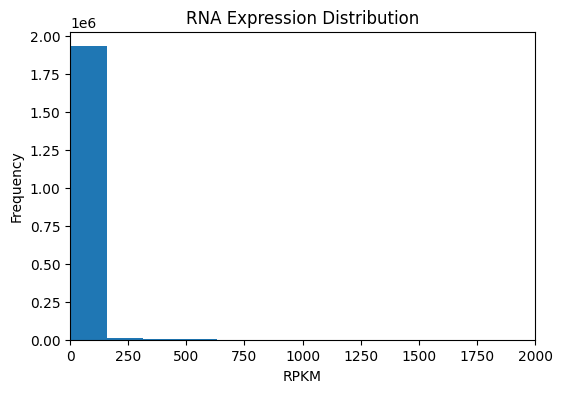

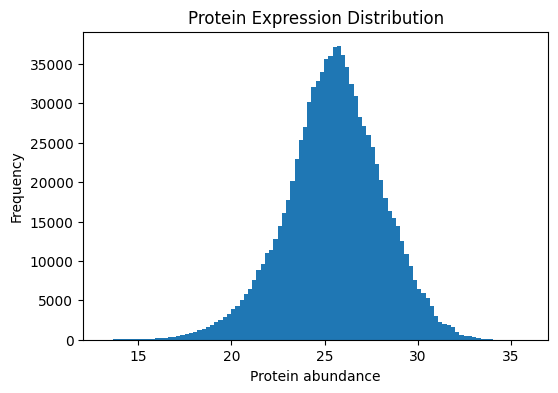


Final cohort
RNA samples: 103
Protein samples: 103
Clinical samples: 103

Data preprocessing completed.


In [1]:
# ==========================================
# Phase 1 — Data Preprocessing
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------
# 1. Load datasets
# ------------------------------------------

common_pairs = pd.read_csv(
    "CPTAC/common_pairs_ccrcc.csv"
)

clinical = pd.read_csv(
    "CPTAC/patient_clean_ccrcc.csv"
)

rna = pd.read_csv(
    "CPTAC/rna_rpkm_ccrcc.csv"
)

protein = pd.read_csv(
    "CPTAC/protein_tmt_ccrcc.csv"
)

print("Clinical:", clinical.shape)
print("RNA:", rna.shape)
print("Protein:", protein.shape)

# ------------------------------------------
# 2. Keep tumour samples only
# ------------------------------------------

tumor_pairs = common_pairs[
    common_pairs["tissue_type"] == "tumor"
].copy()

tumor_case_ids = (
    tumor_pairs["case_id"]
    .tolist()
)

print(
    "\nTumour samples:",
    len(tumor_case_ids)
)

# ------------------------------------------
# 3. Sample mapping
# ------------------------------------------

rna_dict = dict(
    zip(
        tumor_pairs["rna_id"],
        tumor_pairs["case_id"]
    )
)

rna = rna.rename(
    columns=rna_dict
)

protein_dict = dict(
    zip(
        tumor_pairs["cpt_id"],
        tumor_pairs["case_id"]
    )
)

protein = protein.rename(
    columns=protein_dict
)

# ------------------------------------------
# 4. Keep tumour samples
# ------------------------------------------

rna = rna[
    ["feature"] +
    [
        c for c in rna.columns
        if c in tumor_case_ids
    ]
]

protein = protein[
    ["feature"] +
    [
        c for c in protein.columns
        if c in tumor_case_ids
    ]
]

clinical = clinical[
    clinical["case_id"]
    .isin(tumor_case_ids)
].copy()

print("\nAfter tumour filtering")

print("RNA:", rna.shape)
print("Protein:", protein.shape)
print("Clinical:", clinical.shape)

# ------------------------------------------
# 5. Histology check
# ------------------------------------------

print("\nHistology distribution")

print(
    clinical["histologic_type"]
    .value_counts()
)

# ------------------------------------------
# 6. Keep ccRCC only
# ------------------------------------------

clinical = clinical[
    clinical["histologic_type"]
    ==
    "Clear cell renal cell carcinoma"
].copy()

ccrcc_cases = (
    clinical["case_id"]
    .tolist()
)

rna = rna[
    ["feature"] +
    [
        c for c in rna.columns
        if c in ccrcc_cases
    ]
]

protein = protein[
    ["feature"] +
    [
        c for c in protein.columns
        if c in ccrcc_cases
    ]
]

print("\nAfter ccRCC filtering")

print("RNA:", rna.shape)
print("Protein:", protein.shape)
print("Clinical:", clinical.shape)

# ------------------------------------------
# 7. Grade balance check
# ------------------------------------------

print("\nGrade distribution")

print(
    clinical["grade_bin"]
    .value_counts()
)

clinical["y"] = (
    clinical["grade_bin"]
    .map({
        "Low": 0,
        "High": 1
    })
)

# ------------------------------------------
# 8. Missing value check
# ------------------------------------------

print("\nMissing values")

print(
    "RNA:",
    rna.isna().sum().sum()
)

print(
    "Protein:",
    protein.isna().sum().sum()
)

print(
    "Clinical:",
    clinical.isna().sum().sum()
)

# ------------------------------------------
# 9. Duplicate gene check
# ------------------------------------------

print("\nDuplicated genes")

n_dup = (
    rna["feature"]
    .duplicated()
    .sum()
)

print(
    "RNA duplicated genes:",
    n_dup
)

# ------------------------------------------
# 10. Remove all-zero genes
# ------------------------------------------

all_zero = (
    rna.iloc[:,1:]
    .sum(axis=1)
    == 0
)

print(
    "\nAll-zero genes:",
    all_zero.sum()
)

rna = rna.loc[
    ~all_zero
].copy()

print(
    "RNA shape after removing all-zero genes:",
    rna.shape
)

# ------------------------------------------
# 11. Remove duplicated genes
# ------------------------------------------

rna["mean_expression"] = (
    rna.iloc[:,1:]
    .mean(axis=1)
)

rna = (
    rna
    .sort_values(
        "mean_expression",
        ascending=False
    )
    .drop_duplicates(
        subset="feature",
        keep="first"
    )
)

rna = rna.drop(
    columns=["mean_expression"]
)

print(
    "\nRemaining duplicated genes:",
    rna["feature"]
    .duplicated()
    .sum()
)

# ------------------------------------------
# 12. Expression distribution check
# ------------------------------------------

rna_values = (
    rna.iloc[:,1:]
    .values
    .flatten()
)

protein_values = (
    protein.iloc[:,1:]
    .values
    .flatten()
)

print("\nRNA distribution")

print(
    "Min:",
    np.min(rna_values)
)

print(
    "Median:",
    np.median(rna_values)
)

print(
    "Max:",
    np.max(rna_values)
)

print("\nProtein distribution")

print(
    "Min:",
    np.nanmin(protein_values)
)

print(
    "Median:",
    np.nanmedian(protein_values)
)

print(
    "Max:",
    np.nanmax(protein_values)
)

# ------------------------------------------
# 13. RNA histogram
# ------------------------------------------

plt.figure(figsize=(6,4))

plt.hist(
    rna_values,
    bins=100
)

plt.xlim(0, 2000)

plt.xlabel("RPKM")
plt.ylabel("Frequency")
plt.title("RNA Expression Distribution")

plt.show()



# ------------------------------------------
# 14. Protein histogram
# ------------------------------------------

plt.figure(figsize=(6,4))

plt.hist(
    protein_values,
    bins=100
)

plt.title(
    "Protein Expression Distribution"
)

plt.xlabel("Protein abundance")

plt.ylabel("Frequency")

plt.show()

# ------------------------------------------
# 15. Final consistency check
# ------------------------------------------

print("\nFinal cohort")

print(
    "RNA samples:",
    len(rna.columns)-1
)

print(
    "Protein samples:",
    len(protein.columns)-1
)

print(
    "Clinical samples:",
    len(clinical)
)

# ------------------------------------------
# 16. Save cleaned datasets
# ------------------------------------------

rna.to_csv(
    "rna_ccrcc_clean.csv",
    index=False
)

protein.to_csv(
    "protein_ccrcc_clean.csv",
    index=False
)

clinical.to_csv(
    "clinical_ccrcc_clean.csv",
    index=False
)

print(
    "\nData preprocessing completed."
)

In [2]:
clinical.isna().sum().sort_values(ascending=False)

sarcomatoid_percent         100
race                         40
age                           1
case_id                       0
stage_bin                     0
grade_bin                     0
days_to_last_contact_12m      0
vital_status_12m              0
serum_calcium                 0
platelets                     0
white_cell_count              0
hemoglobin                    0
pM                            0
sarcomatoid_features          0
gender                        0
pN                            0
pT                            0
tumor_stage                   0
histologic_grade              0
histologic_type               0
tumor_size_cm                 0
BMI                           0
y                             0
dtype: int64

In [3]:
protein_missing_rate = (
    protein.iloc[:,1:]
    .isna()
    .mean(axis=1)
)

protein_missing_rate.describe()

count    11355.000000
mean         0.186233
std          0.310646
min          0.000000
25%          0.000000
50%          0.000000
75%          0.281553
max          0.970874
dtype: float64

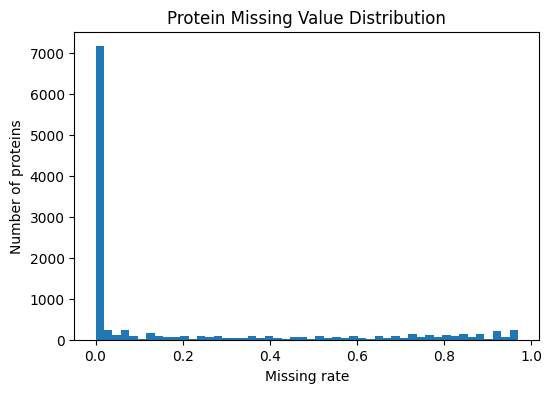

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.hist(
    protein_missing_rate,
    bins=50
)

plt.xlabel("Missing rate")
plt.ylabel("Number of proteins")
plt.title("Protein Missing Value Distribution")

plt.show()

In [5]:
protein_missing_rate = (
    protein.iloc[:,1:]
    .isna()
    .mean(axis=1)
)

print(
    (protein_missing_rate > 0.3).sum()
)

print(
    (protein_missing_rate > 0.5).sum()
)

2761
2175


In [6]:
# Deletion of highly missing proteins
protein_missing_rate = (
    protein.iloc[:,1:]
    .isna()
    .mean(axis=1)
)

protein_filtered = protein.loc[
    protein_missing_rate <= 0.3
].copy()

print(protein_filtered.shape)

(8594, 104)


In [7]:
# Fill in the remaining missing values
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(
    strategy="median"
)

protein_imputed = pd.DataFrame(
    imputer.fit_transform(
        protein_filtered.iloc[:,1:]
    ),
    columns=protein_filtered.columns[1:]
)

protein_imputed.insert(
    0,
    "feature",
    protein_filtered["feature"].values
)

# check
protein_imputed.isna().sum().sum()



0

In [8]:
protein_imputed.to_csv(
    "protein_imputed.csv",
    index=False
)

In [9]:
rna.shape

(18985, 104)

In [10]:
# RNA Low-expression filtering exploration

for cutoff in [0.5, 1, 2]:
    
    keep = (
        (rna.iloc[:,1:] > cutoff)
        .sum(axis=1)
        >= 10
    )
    
    print(
        f"Cutoff={cutoff}",
        keep.sum()
    )


Cutoff=0.5 15472
Cutoff=1 14515
Cutoff=2 13417


In [11]:
# Low-expression filtering

keep = (
    (rna.iloc[:,1:] > 1)
    .sum(axis=1)
    >= 10
)

rna_filtered = rna.loc[keep].copy()

print("RNA shape after low-expression filtering:")
print(rna_filtered.shape)

RNA shape after low-expression filtering:
(14515, 104)


In [12]:
rna_filtered.to_csv(
    "rna_low_expression_filtered.csv",
    index=False
)

In [13]:
# RNA variance

rna_var = rna_filtered.iloc[:,1:].var(axis=1)

print(rna_var.describe())

count    1.451500e+04
mean     1.586228e+03
std      4.506781e+04
min      3.390965e-02
25%      1.877794e+00
50%      7.277219e+00
75%      3.323806e+01
max      4.569819e+06
dtype: float64


In [14]:
# use log
import numpy as np

rna_log = rna_filtered.copy()

rna_log.iloc[:,1:] = np.log2(
    rna_log.iloc[:,1:] + 1
)

rna_var_log = rna_log.iloc[:,1:].var(axis=1)

print(rna_var_log.describe())

count    14515.000000
mean         0.295191
std          0.474973
min          0.016993
25%          0.079874
50%          0.140219
75%          0.312821
max         10.333726
dtype: float64


In [15]:
rna_log.to_csv(
    "rna_log2_filtered.csv",
    index=False
)

In [16]:
#----------------------------------------
## EDA
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import pandas as pd
import matplotlib.pyplot as plt

# RNA matrix

rna = pd.read_csv("rna_log2_filtered.csv")

# gene × sample
X = rna.iloc[:, 1:]

# sample × gene
X = X.T

# sample IDs
X.index.name = "case_id"

# --------------------------
# Standardization
# --------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# PCA

pca = PCA(n_components=2)

pca_result = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    pca_result,
    columns=["PC1", "PC2"]
)

pca_df["case_id"] = X.index

# Merge clinical labels

clinical = pd.read_csv(
    "clinical_ccrcc_clean.csv"
)

pca_df = pca_df.merge(
    clinical[["case_id", "grade_bin"]],
    on="case_id"
)

# Explained variance

print(
    "PC1:",
    round(
        pca.explained_variance_ratio_[0] * 100,
        2
    ),
    "%"
)

print(
    "PC2:",
    round(
        pca.explained_variance_ratio_[1] * 100,
        2
    ),
    "%"
)

PC1: 12.17 %
PC2: 8.61 %


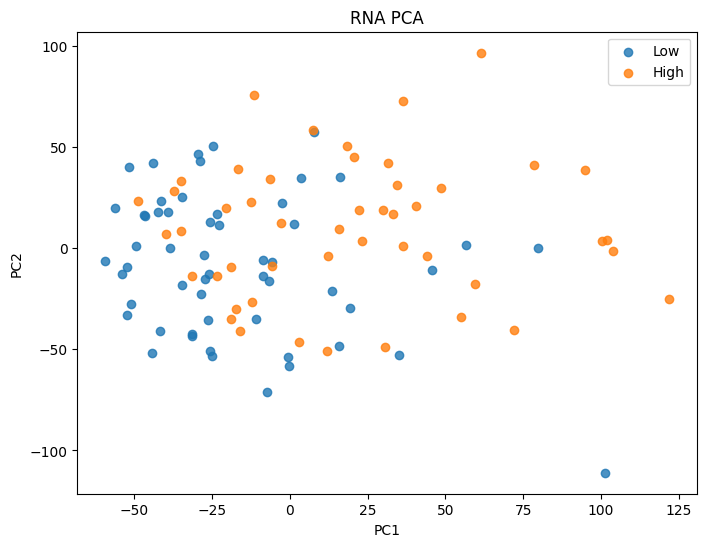

In [17]:
plt.figure(figsize=(8,6))

for grade in ["Low", "High"]:

    subset = pca_df[
        pca_df["grade_bin"] == grade
    ]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=grade,
        alpha=0.8
    )

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("RNA PCA")

plt.legend()

plt.savefig(
    "RNA_pca.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [18]:
pca_df.to_csv(
    "rna_pca_scores.csv",
    index=False
)

Protein shape: (8594, 104)
Clinical shape: (103, 23)
PCA matrix: (103, 8594)
PC1: 10.24%
PC2: 8.10%


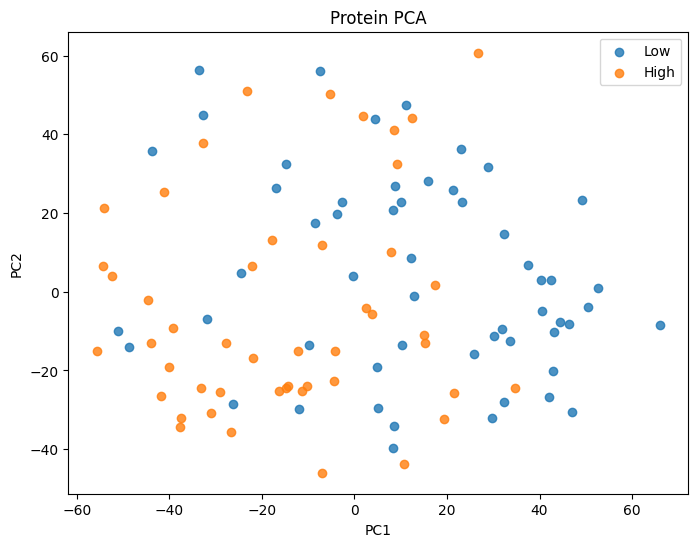


Top 10 PCA outliers
           PC1        PC2 grade_bin   distance
58   66.088981  -8.445015       Low  66.626359
49   26.789643  60.720630      High  66.367762
9   -33.508716  56.286148       Low  65.505454
102 -54.210030  21.260457      High  58.230013
90  -55.746660 -14.942733      High  57.714603
2    -7.446972  56.076526       Low  56.568845
66  -43.707719  35.786463       Low  56.489253
23  -23.320951  51.094359      High  56.164939
55   47.122768 -30.543896       Low  56.155898
54  -32.664275  44.921795       Low  55.542079


In [19]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# protein PCA

protein = pd.read_csv("protein_imputed.csv")

clinical = pd.read_csv(
    "clinical_ccrcc_clean.csv"
)

print("Protein shape:", protein.shape)
print("Clinical shape:", clinical.shape)


# Build PCA matrix
# Rows = samples
# Columns = proteins

X = protein.iloc[:,1:].T

print("PCA matrix:", X.shape)

# Standardization

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pc1_var = (
    pca.explained_variance_ratio_[0]
    * 100
)

pc2_var = (
    pca.explained_variance_ratio_[1]
    * 100
)

print(
    f"PC1: {pc1_var:.2f}%"
)

print(
    f"PC2: {pc2_var:.2f}%"
)

# Match grade labels

grade_map = clinical.set_index(
    "case_id"
)["grade_bin"]

sample_grade = grade_map.loc[
    X.index
]

# PCA dataframe

pca_df = pd.DataFrame({
    "PC1": X_pca[:,0],
    "PC2": X_pca[:,1],
    "grade_bin": sample_grade.values
})

# PCA plot

plt.figure(figsize=(8,6))

for grade in ["Low","High"]:

    subset = pca_df[
        pca_df["grade_bin"] == grade
    ]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=grade,
        alpha=0.8
    )

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("Protein PCA")

plt.legend()

plt.savefig(
    "protein_pca.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Check potential outliers

pca_df["distance"] = (
    pca_df["PC1"]**2 +
    pca_df["PC2"]**2
) ** 0.5

print("\nTop 10 PCA outliers")

print(
    pca_df.sort_values(
        "distance",
        ascending=False
    ).head(10)
)

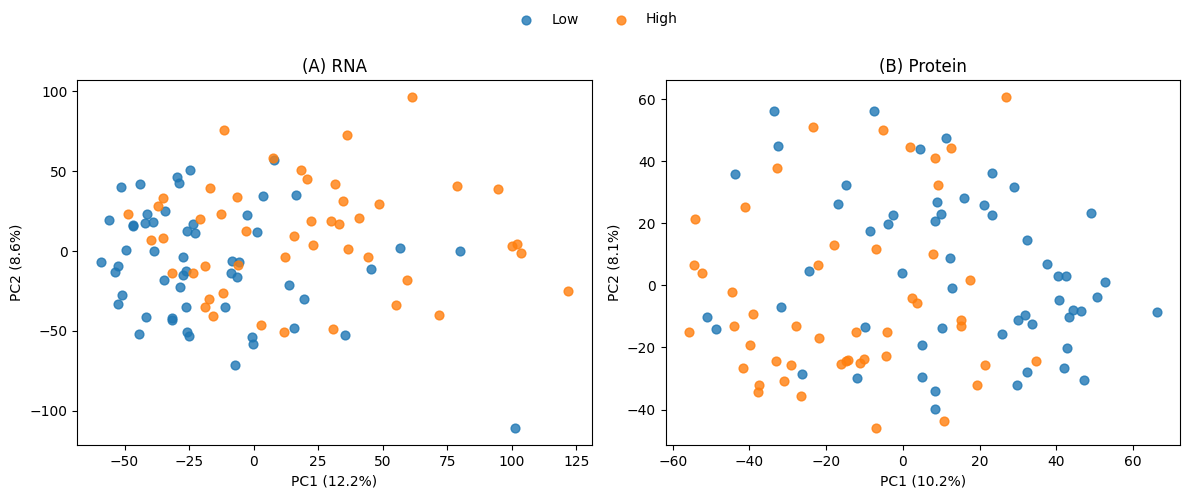

In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Read data
# -----------------------------

clinical = pd.read_csv("clinical_ccrcc_clean.csv")

# ========= RNA =========

rna = pd.read_csv("rna_log2_filtered.csv")

X_rna = rna.iloc[:,1:].T

X_rna_scaled = StandardScaler().fit_transform(X_rna)

pca_rna = PCA(n_components=2)

rna_pc = pca_rna.fit_transform(X_rna_scaled)

rna_df = pd.DataFrame({
    "PC1": rna_pc[:,0],
    "PC2": rna_pc[:,1],
    "Grade": clinical.set_index("case_id").loc[X_rna.index]["grade_bin"].values
})

rna_pc1 = pca_rna.explained_variance_ratio_[0]*100
rna_pc2 = pca_rna.explained_variance_ratio_[1]*100

# ========= Protein =========

protein = pd.read_csv("protein_imputed.csv")

X_protein = protein.iloc[:,1:].T

X_protein_scaled = StandardScaler().fit_transform(X_protein)

pca_protein = PCA(n_components=2)

protein_pc = pca_protein.fit_transform(X_protein_scaled)

protein_df = pd.DataFrame({
    "PC1": protein_pc[:,0],
    "PC2": protein_pc[:,1],
    "Grade": clinical.set_index("case_id").loc[X_protein.index]["grade_bin"].values
})

protein_pc1 = pca_protein.explained_variance_ratio_[0]*100
protein_pc2 = pca_protein.explained_variance_ratio_[1]*100

# ===============================
# Combined Figure
# ===============================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12,5),
    sharex=False,
    sharey=False
)

colors = {
    "Low":"tab:blue",
    "High":"tab:orange"
}

# ---------- RNA ----------

for grade in ["Low","High"]:

    subset = rna_df[rna_df["Grade"]==grade]

    axes[0].scatter(
        subset["PC1"],
        subset["PC2"],
        color=colors[grade],
        alpha=0.8,
        s=40,
        label=grade
    )

axes[0].set_title("(A) RNA")
axes[0].set_xlabel(f"PC1 ({rna_pc1:.1f}%)")
axes[0].set_ylabel(f"PC2 ({rna_pc2:.1f}%)")

# ---------- Protein ----------

for grade in ["Low","High"]:

    subset = protein_df[
        protein_df["Grade"]==grade
    ]

    axes[1].scatter(
        subset["PC1"],
        subset["PC2"],
        color=colors[grade],
        alpha=0.8,
        s=40
    )

axes[1].set_title("(B) Protein")
axes[1].set_xlabel(f"PC1 ({protein_pc1:.1f}%)")
axes[1].set_ylabel(f"PC2 ({protein_pc2:.1f}%)")

# Shared legend

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    frameon=False
)

plt.tight_layout(rect=[0,0,1,0.92])

plt.savefig(
    "Figure1_PCA_RNA_Protein.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Top variable gene matrix:
(30, 104)

Clustering matrix:
(30, 103)


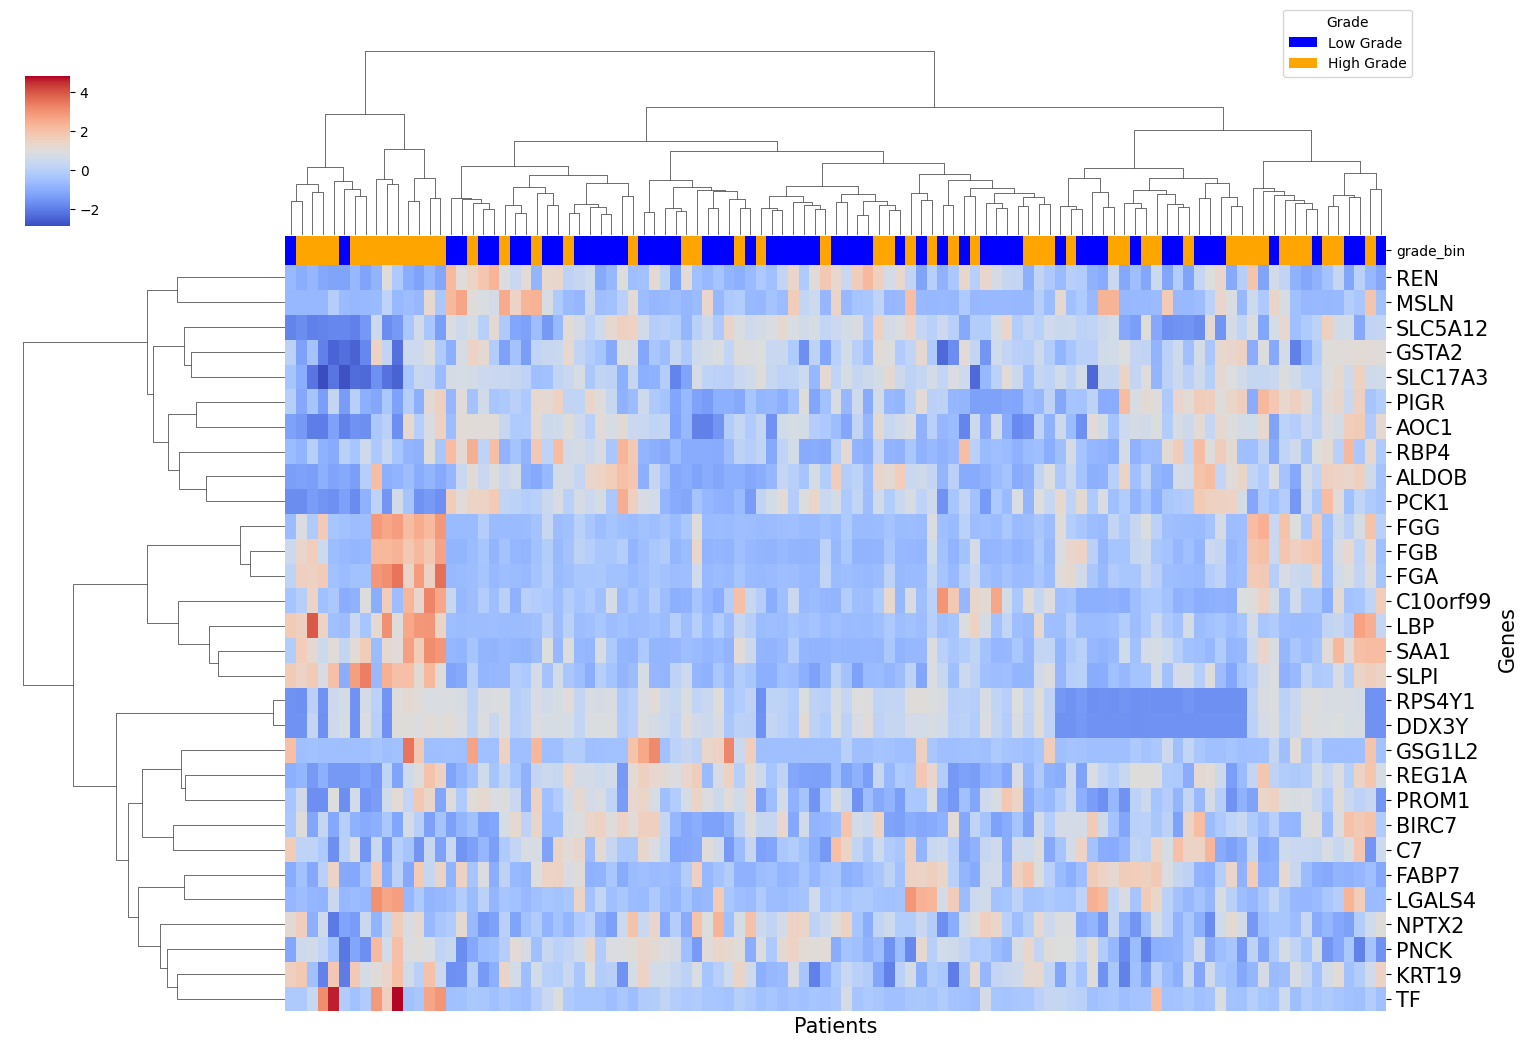

In [21]:
# =====================================================
# RNA Hierarchical Clustering
# Top 30 Most Variable Genes
# =====================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# =====================================================
# Variance calculation
# =====================================================

rna_var = rna_log.iloc[:, 1:].var(axis=1)

# Select Top 30 variable genes

top30_idx = (
    rna_var
    .sort_values(ascending=False)
    .head(30)
    .index
)

rna_top30 = rna_log.loc[top30_idx].copy()

print("Top variable gene matrix:")
print(rna_top30.shape)

# =====================================================
# Expression matrix
# Rows = genes
# Columns = samples
# =====================================================

rna_matrix = (
    rna_top30
    .set_index("feature")
)

print("\nClustering matrix:")
print(rna_matrix.shape)

# =====================================================
# Z-score normalization
# Gene-wise scaling
# =====================================================

rna_matrix_z = rna_matrix.apply(

    lambda x: (x - x.mean()) / x.std(),

    axis=1

)

# =====================================================
# Grade annotation
# =====================================================

sample_grade = (

    clinical

    .set_index("case_id")

    .loc[
        rna_matrix_z.columns,
        "grade_bin"
    ]

)

col_colors = sample_grade.map({

    "Low":"blue",

    "High":"orange"

})

# =====================================================
# Hierarchical clustering
# =====================================================

g = sns.clustermap(

    rna_matrix_z,

    z_score=None,

    cmap="coolwarm",

    row_cluster=True,

    col_cluster=True,

    metric="euclidean",

    method="ward",

    col_colors=col_colors,

    figsize=(15,10),

    xticklabels=False,

    yticklabels=True,

    cbar_pos=(0.02,0.8,0.03,0.15)

)

# =====================================================
# Remove grade label
# =====================================================

g.ax_col_colors.set_ylabel("")

# =====================================================
# Gene font size
# =====================================================

g.ax_heatmap.tick_params(

    axis="y",

    labelsize=15

)

g.ax_heatmap.set_xlabel(
    "Patients",
    fontsize=15
)

g.ax_heatmap.set_ylabel(
    "Genes",   
    fontsize=15
)

# =====================================================
# Legend
# =====================================================

handles = [

    Patch(

        facecolor="blue",

        label="Low Grade"

    ),

    Patch(

        facecolor="orange",

        label="High Grade"

    )

]

g.ax_col_dendrogram.legend(

    handles=handles,

    title="Grade",

    bbox_to_anchor=(0.90,1.20),

    loc="upper left"

)

g.savefig(
    "RNA_cluster.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

Top variable protein matrix:
(30, 104)

Clustering matrix:
(30, 103)


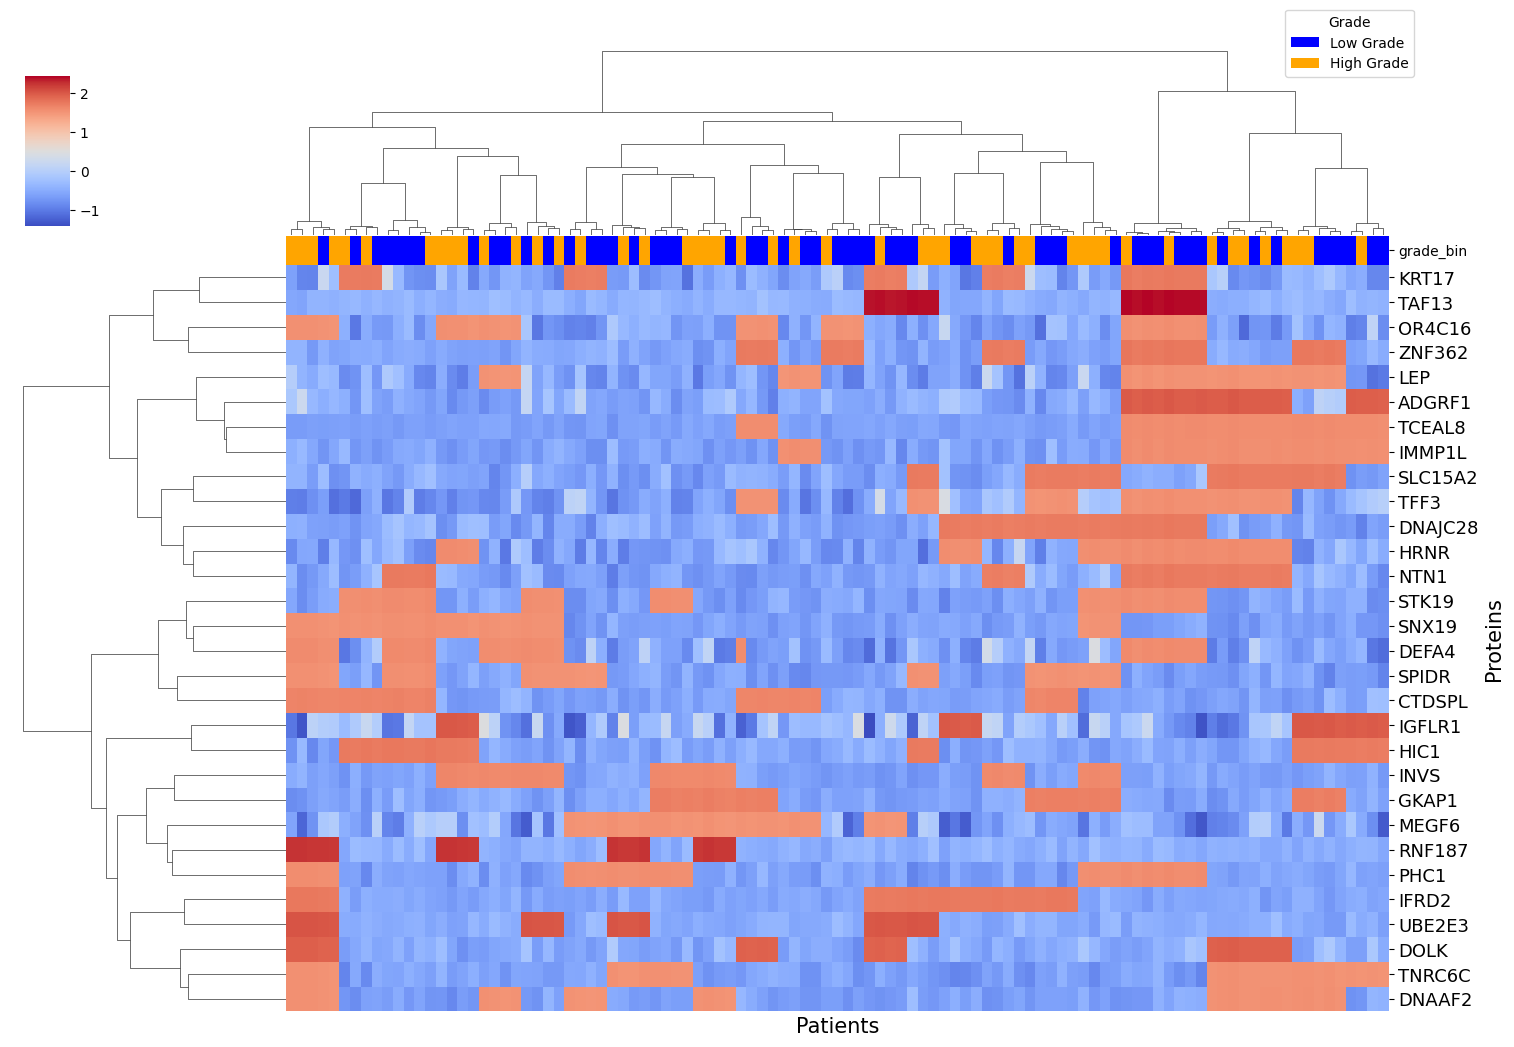

In [22]:
# =====================================================
# Protein Hierarchical Clustering
# Top 30 Most Variable Proteins
# =====================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# =====================================================
# Load data
# =====================================================

protein = pd.read_csv("protein_imputed.csv")
clinical = pd.read_csv("clinical_ccrcc_clean.csv")

# =====================================================
# Variance calculation
# =====================================================

protein_var = protein.iloc[:, 1:].var(axis=1)

# =====================================================
# Select Top 30 variable proteins

top30_idx = (
    protein_var
    .sort_values(ascending=False)
    .head(30)
    .index
)

protein_top30 = protein.loc[top30_idx].copy()

print("Top variable protein matrix:")
print(protein_top30.shape)

# =====================================================
# Expression matrix
# Rows = proteins
# Columns = samples
# =====================================================

protein_matrix = protein_top30.set_index(
    protein.columns[0]
)

print("\nClustering matrix:")
print(protein_matrix.shape)

# =====================================================
# Z-score normalization
# Normalize each protein
# =====================================================

protein_matrix_z = protein_matrix.sub(
    protein_matrix.mean(axis=1),
    axis=0
).div(
    protein_matrix.std(axis=1),
    axis=0
)

# =====================================================
# Grade annotation
# =====================================================

grade_map = clinical.set_index(
    "case_id"
)["grade_bin"]

sample_grade = grade_map.loc[
    protein_matrix_z.columns
]

col_colors = sample_grade.map({
    "Low": "blue",
    "High": "orange"
})

# =====================================================
# Hierarchical clustering
# =====================================================

g = sns.clustermap(

    protein_matrix_z,

    cmap="coolwarm",

    row_cluster=True,
    col_cluster=True,

    col_colors=col_colors,

    xticklabels=False,
    yticklabels=True,

    metric="euclidean",
    method="ward",

    figsize=(15,10),        

    cbar_pos=(0.02,0.80,0.03,0.15)
)


# =====================================================
# Remove label beside color bar
# =====================================================

g.ax_col_colors.set_ylabel("")

# =====================================================
# Protein labels
# =====================================================

g.ax_heatmap.tick_params(
    axis="y",
    labelsize=13
)

# =====================================================
# Legend
# =====================================================

g.ax_heatmap.set_xlabel(
    "Patients",
    fontsize=15
)

g.ax_heatmap.set_ylabel(
    "Proteins", 
    fontsize=15
)



handles = [

    Patch(
        facecolor="blue",
        label="Low Grade"
    ),

    Patch(
        facecolor="orange",
        label="High Grade"
    )

]

g.ax_col_dendrogram.legend(

    handles=handles,

    title="Grade",

    bbox_to_anchor=(0.90,1.20),

    loc="upper left"

)

g.savefig(
    "Protein_cluster.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

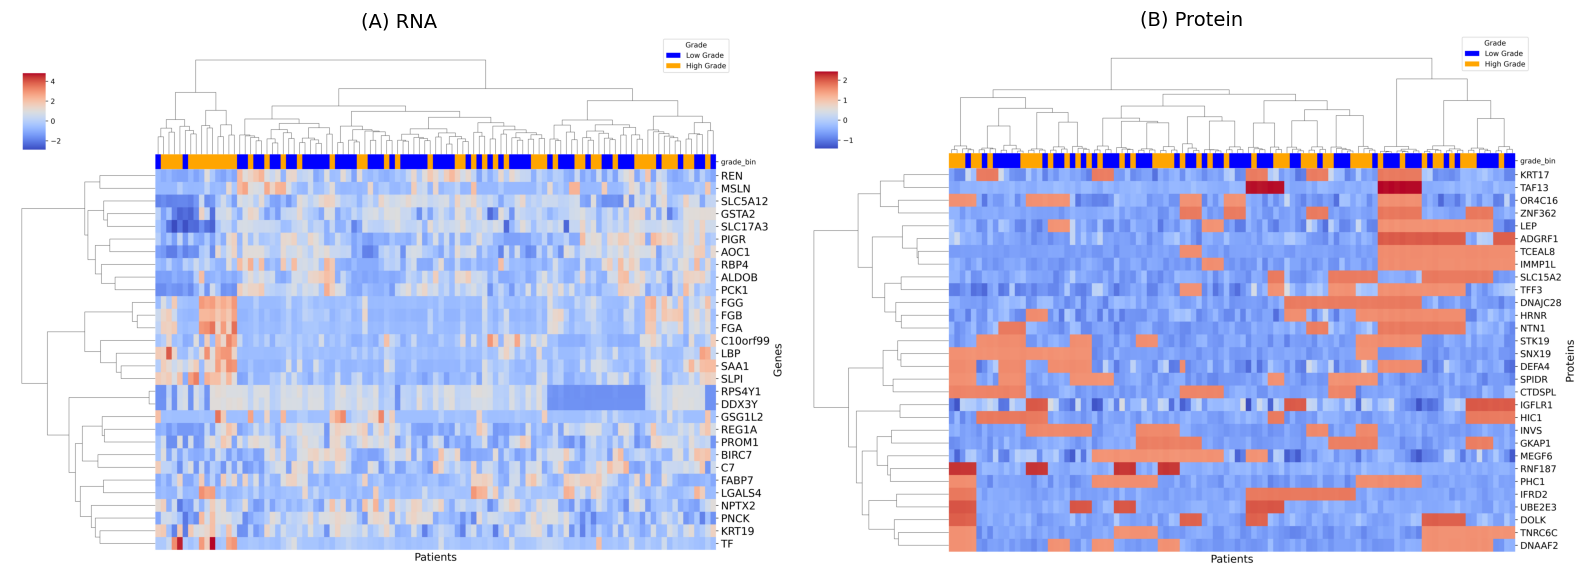

In [23]:
from PIL import Image
import matplotlib.pyplot as plt

# Read figures
rna = Image.open("RNA_cluster.png")
protein = Image.open("Protein_cluster.png")

# Plot
fig, axes = plt.subplots(
    1,
    2,
    figsize=(16,10)
)

axes[0].imshow(rna)
axes[0].axis("off")
axes[0].set_title("(A) RNA", fontsize=14)

axes[1].imshow(protein)
axes[1].axis("off")
axes[1].set_title("(B) Protein", fontsize=14)

plt.tight_layout()

plt.savefig(
    "Figure2_HierarchicalClustering.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

RNA variance summary
count    14515.000000
mean         0.295191
std          0.474973
min          0.016993
25%          0.079874
50%          0.140219
75%          0.312821
max         10.333726
dtype: float64


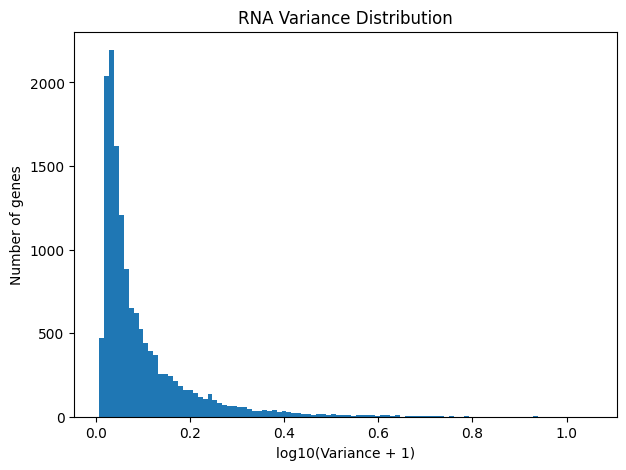


Top variable genes
Top 75% genes: 10886
Top 50% genes: 7257
Top 25% genes: 3629


In [24]:
# =====================================================
# RNA Variance Assessment
# =====================================================

import numpy as np
import matplotlib.pyplot as plt

# Gene variance
rna_var = rna_log.iloc[:, 1:].var(axis=1)

# Summary statistics
print("RNA variance summary")
print(rna_var.describe())

# Variance distribution
plt.figure(figsize=(7,5))

plt.hist(
    np.log10(rna_var + 1),
    bins=100
)

plt.xlabel("log10(Variance + 1)")
plt.ylabel("Number of genes")
plt.title("RNA Variance Distribution")

plt.show()

# Top variable genes assessment
print("\nTop variable genes")

for p in [0.25, 0.5, 0.75]:

    cutoff = rna_var.quantile(p)

    keep = rna_var > cutoff

    print(
        f"Top {(1-p)*100:.0f}% genes:",
        keep.sum()
    )

Protein variance summary
count    8594.000000
mean        0.269605
std         0.624206
min         0.005887
25%         0.028307
50%         0.062184
75%         0.178508
max        11.641441
dtype: float64


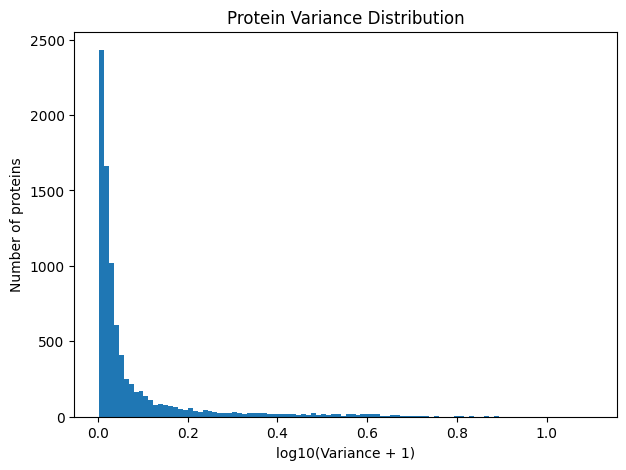


Top variable proteins
Top 75% proteins: 6445
Top 50% proteins: 4297
Top 25% proteins: 2149


In [25]:
# =====================================================
# Protein Variance Assessment
# =====================================================

import numpy as np
import matplotlib.pyplot as plt

# Protein variance
protein_var = protein_imputed.iloc[:, 1:].var(axis=1)

# Summary statistics
print("Protein variance summary")
print(protein_var.describe())

# Variance distribution
plt.figure(figsize=(7,5))

plt.hist(
    np.log10(protein_var + 1),
    bins=100
)

plt.xlabel("log10(Variance + 1)")
plt.ylabel("Number of proteins")
plt.title("Protein Variance Distribution")

plt.show()

# Top variable proteins assessment
print("\nTop variable proteins")

for p in [0.25, 0.5, 0.75]:

    cutoff = protein_var.quantile(p)

    keep = protein_var > cutoff

    print(
        f"Top {(1-p)*100:.0f}% proteins:",
        keep.sum()
    )

In [26]:
# =====================================================
# RNA DEA
# All 103 ccRCC samples
# For GO / KEGG / RNA-Protein Integration
# =====================================================

import pandas as pd
import numpy as np

from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

# =====================================================
# Sample groups
# =====================================================

low_samples = clinical.loc[
    clinical["grade_bin"] == "Low",
    "case_id"
]

high_samples = clinical.loc[
    clinical["grade_bin"] == "High",
    "case_id"
]

print("Low grade:", len(low_samples))
print("High grade:", len(high_samples))

# =====================================================
# Expression matrix
# =====================================================

expr = rna_log.set_index(
    "feature"
)

expr_low = expr[
    low_samples
]

expr_high = expr[
    high_samples
]

# =====================================================
# DEA
# =====================================================

results = []

for gene in expr.index:

    low_values = expr_low.loc[gene]

    high_values = expr_high.loc[gene]

    # log2FC

    log2FC = (
        high_values.mean()
        -
        low_values.mean()
    )

    # Welch t-test

    stat, pvalue = ttest_ind(
        high_values,
        low_values,
        equal_var=False
    )

    results.append([
        gene,
        log2FC,
        pvalue
    ])

# =====================================================
# DataFrame
# =====================================================

dea_all = pd.DataFrame(

    results,

    columns=[
        "Gene",
        "log2FC",
        "P.Value"
    ]
)

# =====================================================
# FDR correction
# =====================================================

dea_all["adj.P.Val"] = multipletests(
    dea_all["P.Value"],
    method="fdr_bh"
)[1]

# =====================================================
# Sort
# =====================================================

dea_all = dea_all.sort_values(
    "adj.P.Val"
)

# =====================================================
# Results
# =====================================================

print(
    "Genes tested:",
    len(dea_all)
)

print(
    "FDR < 0.05:",
    (
        dea_all["adj.P.Val"] < 0.05
    ).sum()
)

print(
    "|log2FC| > 1:",
    (
        (dea_all["adj.P.Val"] < 0.05)
        &
        (abs(dea_all["log2FC"]) > 1)
    ).sum()
)

# =====================================================
# Save
# =====================================================

dea_all.to_csv(
    "RNA_DEA_AllSamples.csv",
    index=False
)

print(
    "\nSaved:"
)

print(
    "RNA_DEA_AllSamples.csv"
)

Low grade: 55
High grade: 48
Genes tested: 14515
FDR < 0.05: 2476
|log2FC| > 1: 33

Saved:
RNA_DEA_AllSamples.csv


       Gene    log2FC  adj.P.Val
338     FGB  2.459996   0.004393
466     FGG  2.273127   0.005215
5611  FABP4 -1.352893   0.001299
2190   MGAM -1.316917   0.001773


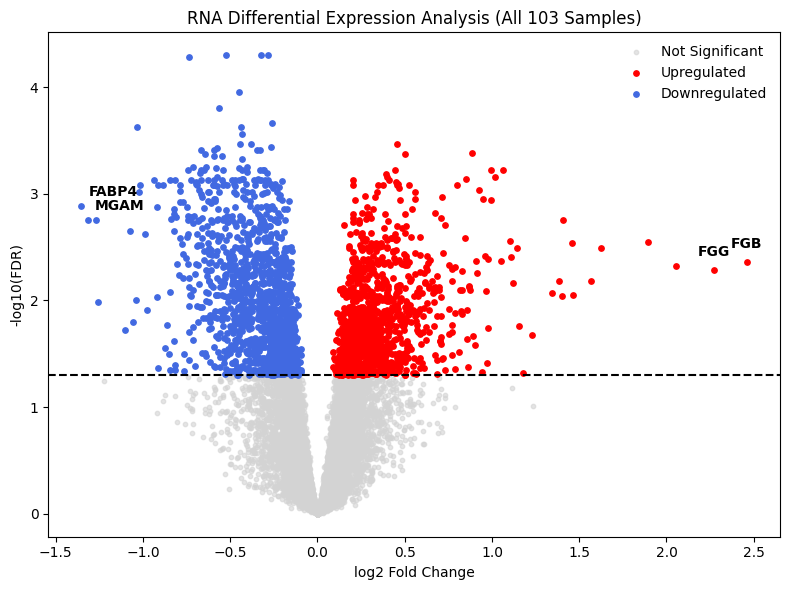

In [27]:
# =====================================================

# Volcano Plot

# All 103 Samples

# =====================================================



import numpy as np

import matplotlib.pyplot as plt



dea_all["minus_log10_FDR"] = -np.log10(

    dea_all["adj.P.Val"]

)



# =====================================================

# Category

# =====================================================



dea_all["Status"] = "Not Significant"



dea_all.loc[
    (dea_all["adj.P.Val"] < 0.05)
    &
    (dea_all["log2FC"] > 0),
    "Status"
] = "Upregulated"

dea_all.loc[
    (dea_all["adj.P.Val"] < 0.05)
    &
    (dea_all["log2FC"] < 0),
    "Status"
] = "Downregulated"


# =====================================================

# Plot

# =====================================================



plt.figure(figsize=(8,6))



plt.scatter(

    dea_all.loc[

        dea_all["Status"]=="Not Significant",

        "log2FC"

    ],

    dea_all.loc[

        dea_all["Status"]=="Not Significant",

        "minus_log10_FDR"

    ],

    color="lightgrey",

    s=10,

    alpha=0.6,

    label="Not Significant"

)



plt.scatter(

    dea_all.loc[

        dea_all["Status"]=="Upregulated",

        "log2FC"

    ],

    dea_all.loc[

        dea_all["Status"]=="Upregulated",

        "minus_log10_FDR"

    ],

    color="red",

    s=15,

    label="Upregulated"

)



plt.scatter(

    dea_all.loc[

        dea_all["Status"]=="Downregulated",

        "log2FC"

    ],

    dea_all.loc[

        dea_all["Status"]=="Downregulated",

        "minus_log10_FDR"

    ],

    color="royalblue",

    s=15,

    label="Downregulated"

)



# =====================================================

# Threshold

# =====================================================

plt.axhline(

    y=-np.log10(0.05),

    linestyle="--",

    color="black"

)



# =====================================================

# Label genes

# 2 strongest Up + 2 strongest Down

# =====================================================



top_up = (

    dea_all[

        (dea_all["adj.P.Val"] < 0.05)

        &

        (dea_all["log2FC"] > 1)

    ]

    .sort_values(

        "log2FC",

        ascending=False

    )

    .head(2)

)



top_down = (

    dea_all[

        (dea_all["adj.P.Val"] < 0.05)

        &

        (dea_all["log2FC"] < -1)

    ]

    .sort_values(

        "log2FC",

        ascending=True

    )

    .head(2)

)



label_genes = pd.concat([

    top_up,

    top_down

])



print(label_genes[

    ["Gene","log2FC","adj.P.Val"]

])



for _, row in label_genes.iterrows():

    # Downregulated
    if row["log2FC"] < 0:
        offset = (5, 5)
        ha = "left"
        va = "bottom"

    # Upregulated
    else:
        offset = (0, 8)
        ha = "center"
        va = "bottom"

    plt.annotate(

        row["Gene"],

        (
            row["log2FC"],
            row["minus_log10_FDR"]
        ),

        xytext=offset,

        textcoords="offset points",

        fontsize=10,

        fontweight="bold",

        ha=ha,

        va=va

    )



# =====================================================

# Format

# =====================================================



plt.xlabel("log2 Fold Change")



plt.ylabel("-log10(FDR)")



plt.title(

    "RNA Differential Expression Analysis (All 103 Samples)"

)



plt.legend(

    frameon=False

)



plt.tight_layout()



plt.savefig(

    "RNA_Volcano_AllSamples.png",

    dpi=600,

    bbox_inches="tight"

)



plt.show()

Top 30 DEGs:
['RUNX1T1', 'FAM122A', 'TECPR2', 'IL17RD', 'PPP1R13B', 'TRIL', 'ATXN3', 'TIMP3', 'PTPN21', 'C11orf95', 'GIPC3', 'C1RL', 'EFCC1', 'WDR20', 'PEAR1', 'CEP68', 'SOX18', 'SNCAIP', 'HSPA12B', 'SOD2', 'SHE', 'HN1', 'JAM2', 'ARHGEF15', 'GATA2', 'KLHDC1', 'CCDC85A', 'CCM2L', 'ZBTB46', 'LIMS2']
(30, 103)


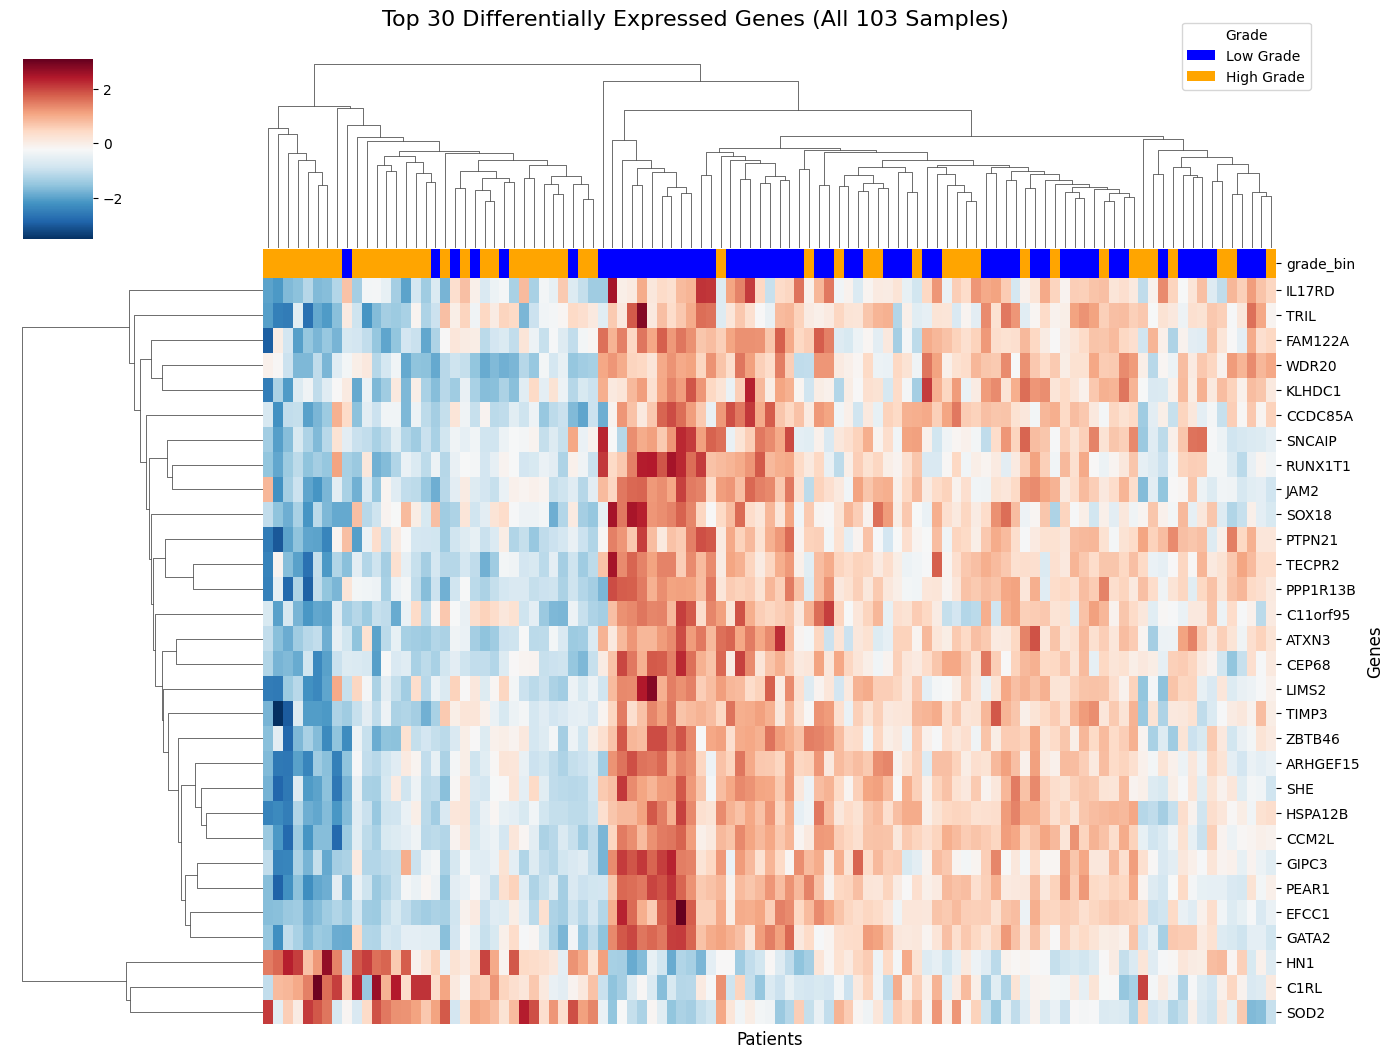

In [28]:
# =====================================================
# RNA Heatmap
# Top 30 DEGs
# All 103 Samples
# =====================================================

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# =====================================================
# Top 30 DEGs
# =====================================================

top30_genes = (
    dea_all
    .sort_values("adj.P.Val")
    .head(30)["Gene"]
)

print("Top 30 DEGs:")
print(top30_genes.tolist())

# =====================================================
# Expression matrix
# =====================================================

expr = rna_log.set_index(
    "feature"
)

heatmap_data = expr.loc[
    top30_genes
]

print(
    heatmap_data.shape
)

# =====================================================
# Grade annotation
# =====================================================

sample_grade = clinical.set_index(
    "case_id"
).loc[
    heatmap_data.columns,
    "grade_bin"
]

col_colors = sample_grade.map({
    "Low": "blue",
    "High": "orange"
})

# =====================================================
# Heatmap
# =====================================================

g = sns.clustermap(

    heatmap_data,

    z_score=0,

    cmap="RdBu_r",

    row_cluster=True,
    col_cluster=True,

    col_colors=col_colors,

    figsize=(14,10),

    xticklabels=False,

    yticklabels=True
)

# =====================================================
# Remove label
# =====================================================

g.ax_col_colors.set_ylabel("")

# =====================================================
# Gene font size
# =====================================================

g.ax_heatmap.tick_params(
    axis="y",
    labelsize=10
)

# =====================================================
# Legend
# =====================================================
g.ax_heatmap.set_xlabel(
    "Patients",
    fontsize=12
)

g.ax_heatmap.set_ylabel(
    "Genes", 
    fontsize=12
)

handles = [

    Patch(
        facecolor="blue",
        label="Low Grade"
    ),

    Patch(
        facecolor="orange",
        label="High Grade"
    )
]

g.ax_col_dendrogram.legend(
    handles=handles,
    title="Grade",
    bbox_to_anchor=(0.9,1.2),
    loc="upper left"
)

# =====================================================
# Title
# =====================================================

g.fig.suptitle(
    "Top 30 Differentially Expressed Genes (All 103 Samples)",
    fontsize=16,
    y=1.03
)

# =====================================================
# Save
# =====================================================

g.savefig(
    "RNA_DEG_Heatmap_AllSamples.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [29]:
# =====================================================
# Protein DEA
# All 103 ccRCC samples
# For GO / KEGG / RNA-Protein Integration
# =====================================================

import pandas as pd
import numpy as np

from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

# =====================================================
# Sample groups
# =====================================================

low_samples = clinical.loc[
    clinical["grade_bin"] == "Low",
    "case_id"
]

high_samples = clinical.loc[
    clinical["grade_bin"] == "High",
    "case_id"
]

print("Low grade:", len(low_samples))
print("High grade:", len(high_samples))

# =====================================================
# Expression matrix
# =====================================================

expr = protein_imputed.set_index(
    "feature"
)

expr_low = expr[
    low_samples
]

expr_high = expr[
    high_samples
]

# =====================================================
# DEA
# =====================================================

results = []

for protein in expr.index:

    low_values = expr_low.loc[protein]

    high_values = expr_high.loc[protein]

    # log2FC
    # Protein data already log-transformed

    log2FC = (
        high_values.mean()
        -
        low_values.mean()
    )

    # Welch t-test

    stat, pvalue = ttest_ind(
        high_values,
        low_values,
        equal_var=False
    )

    results.append([
        protein,
        log2FC,
        pvalue
    ])

# =====================================================
# DataFrame
# =====================================================

protein_dea_all = pd.DataFrame(

    results,

    columns=[
        "Protein",
        "log2FC",
        "P.Value"
    ]
)

# =====================================================
# FDR correction
# =====================================================

protein_dea_all["adj.P.Val"] = multipletests(
    protein_dea_all["P.Value"],
    method="fdr_bh"
)[1]

# =====================================================
# Sort
# =====================================================

protein_dea_all = protein_dea_all.sort_values(
    "adj.P.Val"
)

# =====================================================
# Statistics
# =====================================================

print(
    "Proteins tested:",
    len(protein_dea_all)
)

print(
    "FDR < 0.05:",
    (
        protein_dea_all["adj.P.Val"] < 0.05
    ).sum()
)

print(
    "|log2FC| > 0.5:",
    (
        (protein_dea_all["adj.P.Val"] < 0.05)
        &
        (abs(protein_dea_all["log2FC"]) > 0.5)
    ).sum()
)

# =====================================================
# Save
# =====================================================

protein_dea_all.to_csv(
    "Protein_DEA_AllSamples.csv",
    index=False
)

print("\nSaved:")
print("Protein_DEA_AllSamples.csv")

Low grade: 55
High grade: 48
Proteins tested: 8594
FDR < 0.05: 1205
|log2FC| > 0.5: 8

Saved:
Protein_DEA_AllSamples.csv


Status
Not Significant    7389
Upregulated         638
Downregulated       567
Name: count, dtype: int64


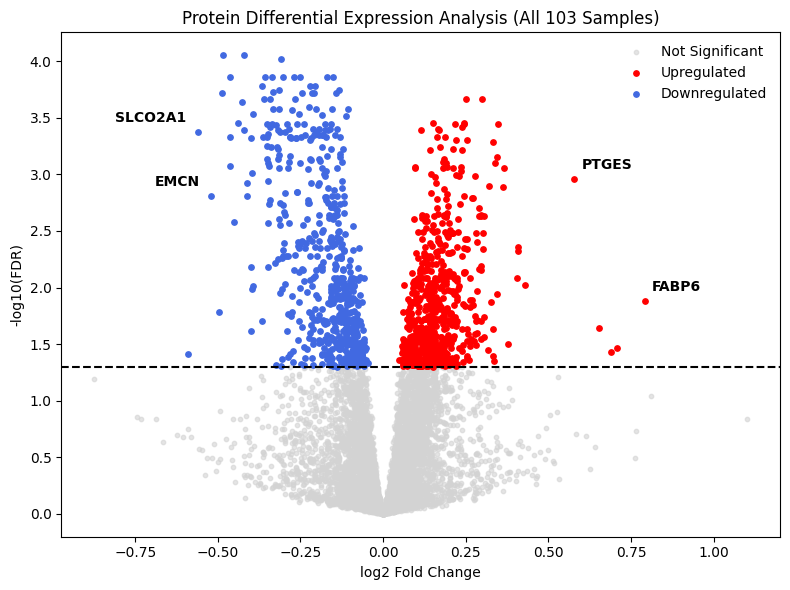

In [30]:
# =====================================================
# Protein Volcano Plot
# All 103 Samples
# =====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================
# -log10(FDR)
# =====================================================

protein_dea_all["minus_log10_FDR"] = -np.log10(
    protein_dea_all["adj.P.Val"]
)

# =====================================================
# Classification
# =====================================================

protein_dea_all["Status"] = "Not Significant"

protein_dea_all.loc[
    (protein_dea_all["adj.P.Val"] < 0.05)
    &
    (protein_dea_all["log2FC"] > 0),
    "Status"
] = "Upregulated"

protein_dea_all.loc[
    (protein_dea_all["adj.P.Val"] < 0.05)
    &
    (protein_dea_all["log2FC"] < 0),
    "Status"
] = "Downregulated"

print(
    protein_dea_all["Status"].value_counts()
)

# =====================================================
# Plot
# =====================================================

plt.figure(figsize=(8,6))

plt.scatter(
    protein_dea_all.loc[
        protein_dea_all["Status"]=="Not Significant",
        "log2FC"
    ],
    protein_dea_all.loc[
        protein_dea_all["Status"]=="Not Significant",
        "minus_log10_FDR"
    ],
    color="lightgrey",
    s=10,
    alpha=0.6,
    label="Not Significant"
)

plt.scatter(
    protein_dea_all.loc[
        protein_dea_all["Status"]=="Upregulated",
        "log2FC"
    ],
    protein_dea_all.loc[
        protein_dea_all["Status"]=="Upregulated",
        "minus_log10_FDR"
    ],
    color="red",
    s=15,
    label="Upregulated"
)

plt.scatter(
    protein_dea_all.loc[
        protein_dea_all["Status"]=="Downregulated",
        "log2FC"
    ],
    protein_dea_all.loc[
        protein_dea_all["Status"]=="Downregulated",
        "minus_log10_FDR"
    ],
    color="royalblue",
    s=15,
    label="Downregulated"
)

# =====================================================
# Threshold lines
# =====================================================



plt.axhline(
    y=-np.log10(0.05),
    linestyle="--",
    color="black"
)

# =====================================================
# Label 2 Up + 2 Down
# =====================================================

top_up = (
    protein_dea_all[
        (protein_dea_all["adj.P.Val"] < 0.05)
        &
        (protein_dea_all["log2FC"] > 0.5)
    ]
    .sort_values("adj.P.Val")
    .head(2)
)

top_down = (
    protein_dea_all[
        (protein_dea_all["adj.P.Val"] < 0.05)
        &
        (protein_dea_all["log2FC"] < -0.5)
    ]
    .sort_values("adj.P.Val")
    .head(2)
)

label_proteins = pd.concat([
    top_up,
    top_down
])

for _, row in label_proteins.iterrows():

    offset = (5, 5)
    ha = "left"
    va = "bottom"

    if row["log2FC"] < 0:
        offset = (-8, 5)
        ha = "right"
        va = "bottom"

    plt.annotate(

        row["Protein"],

        (
            row["log2FC"],
            row["minus_log10_FDR"]
        ),

        xytext=offset,

        textcoords="offset points",

        fontsize=10,

        fontweight="bold",

        ha=ha,

        va=va

    )

# =====================================================
# Format
# =====================================================

plt.xlabel("log2 Fold Change")
plt.ylabel("-log10(FDR)")

plt.title(
    "Protein Differential Expression Analysis (All 103 Samples)"
)

plt.legend(frameon=False)

plt.tight_layout()

plt.savefig(
    "Protein_Volcano_AllSamples.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

Top 30 DEPs:
['CALCRL', 'JAM3', 'HSPA12B', 'SHANK3', 'PPP1R13B', 'CD34', 'TNS2', 'SLC9A3R2', 'SBF2', 'CEP135', 'MCF2L', 'MEF2D', 'GIPC3', 'SHROOM4', 'CRK', 'TBX2', 'ADGRF5', 'CDH13', 'YAP1', 'PRR14', 'ARHGAP6', 'CROCC', 'RASIP1', 'CASKIN2', 'ERGIC3', 'PODXL', 'TM9SF4', 'MMRN2', 'PALM2-AKAP2', 'KANK2']
(30, 103)


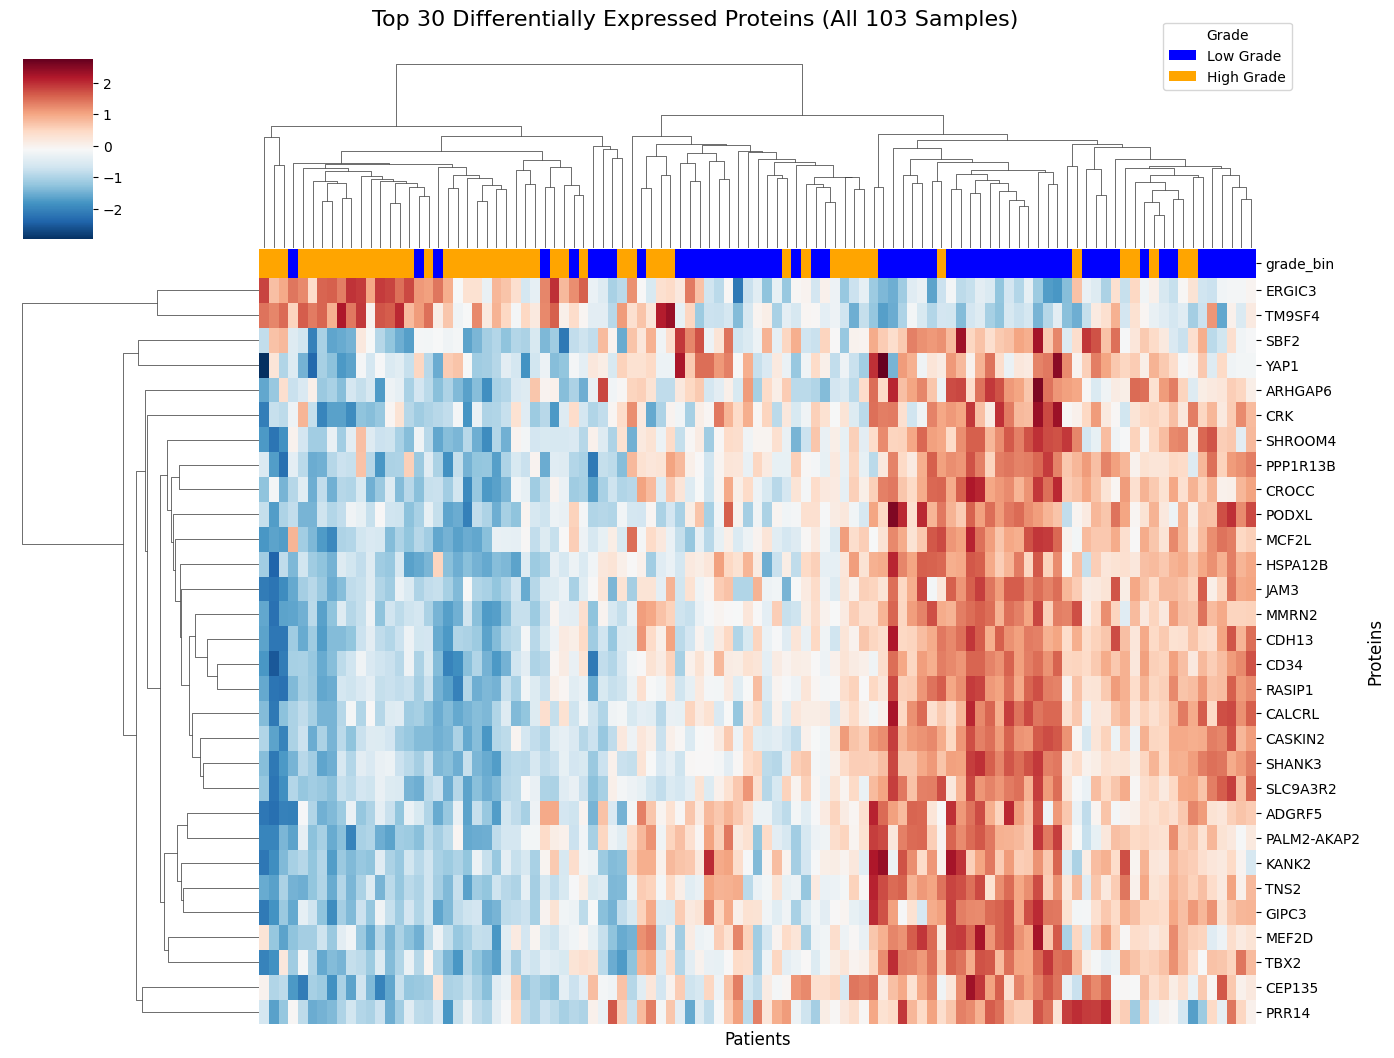

In [31]:
# =====================================================
# Protein Heatmap
# Top 30 Differentially Expressed Proteins
# =====================================================

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# =====================================================
# Top 30 DEP
# =====================================================

top30_proteins = (
    protein_dea_all
    .sort_values("adj.P.Val")
    .head(30)["Protein"]
)

print("Top 30 DEPs:")
print(top30_proteins.tolist())

# =====================================================
# Expression matrix
# =====================================================

expr = protein_imputed.set_index(
    "feature"
)

heatmap_data = expr.loc[
    top30_proteins
]

print(
    heatmap_data.shape
)

# =====================================================
# Grade annotation
# =====================================================

sample_grade = clinical.set_index(
    "case_id"
).loc[
    heatmap_data.columns,
    "grade_bin"
]

col_colors = sample_grade.map({
    "Low": "blue",
    "High": "orange"
})

# =====================================================
# Heatmap
# =====================================================

g = sns.clustermap(

    heatmap_data,

    z_score=0,

    cmap="RdBu_r",

    row_cluster=True,
    col_cluster=True,

    col_colors=col_colors,

    figsize=(14,10),

    xticklabels=False,

    yticklabels=True
)

# =====================================================
# Remove grade label
# =====================================================

g.ax_col_colors.set_ylabel("")

# =====================================================
# Legend
# =====================================================
g.ax_heatmap.set_xlabel(
    "Patients",
    fontsize=12
)

g.ax_heatmap.set_ylabel(
    "Proteins", 
    fontsize=12
)


handles = [

    Patch(
        facecolor="blue",
        label="Low Grade"
    ),

    Patch(
        facecolor="orange",
        label="High Grade"
    )
]

g.ax_col_dendrogram.legend(
    handles=handles,
    title="Grade",
    bbox_to_anchor=(0.9,1.2),
    loc="upper left"
)

# =====================================================
# Title
# =====================================================

g.fig.suptitle(
    "Top 30 Differentially Expressed Proteins (All 103 Samples)",
    fontsize=16,
    y=1.03
)

# =====================================================
# Save
# =====================================================

g.savefig(
    "Protein_DEP_Heatmap_AllSamples.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [32]:
# =====================================================
# RNA DEG List for GO / KEGG
# =====================================================

rna_deg = dea_all[
    dea_all["adj.P.Val"] < 0.05
]

print(
    "RNA DEGs:",
    len(rna_deg)
)

rna_deg["Gene"].to_csv(
    "RNA_DEG_GeneList.txt",
    index=False,
    header=False
)

print(
    "Saved: RNA_DEG_GeneList.txt"
)

RNA DEGs: 2476
Saved: RNA_DEG_GeneList.txt


In [33]:
# =====================================================
# Protein DEP List for GO / KEGG
# =====================================================

protein_dep = protein_dea_all[
    protein_dea_all["adj.P.Val"] < 0.05
]

print(
    "Protein DEPs:",
    len(protein_dep)
)

protein_dep["Protein"].to_csv(
    "Protein_DEP_GeneList.txt",
    index=False,
    header=False
)

print(
    "Saved: Protein_DEP_GeneList.txt"
)

Protein DEPs: 1205
Saved: Protein_DEP_GeneList.txt


In [34]:
# Check overlap part
# RNA significant genes

rna_deg = set(
    dea_all.loc[
        dea_all["adj.P.Val"] < 0.05,
        "Gene"
    ]
)

# Protein significant proteins

protein_dep = set(
    protein_dea_all.loc[
        protein_dea_all["adj.P.Val"] < 0.05,
        "Protein"
    ]
)

# overlap

overlap = rna_deg.intersection(
    protein_dep
)

print(
    "Overlap genes:",
    len(overlap)
)

print(
    sorted(overlap)
)

Overlap genes: 474
['AAGAB', 'ABCC2', 'ABHD12', 'ABRACL', 'ACTR3', 'ADGRF5', 'ADGRL4', 'ADIRF', 'ADSS', 'AFAP1L1', 'AFAP1L2', 'AIFM2', 'AKR1B10', 'AKT1', 'ALDH18A1', 'ALOX5', 'AMOTL1', 'APBB2', 'APOBEC3C', 'APOBEC3G', 'APOL2', 'APPL1', 'ARAP3', 'ARFGAP1', 'ARFGEF2', 'ARHGAP10', 'ARHGAP17', 'ARHGAP31', 'ARHGAP5', 'ARHGAP6', 'ARHGEF10', 'ARHGEF17', 'ARHGEF40', 'ARID4A', 'ARL1', 'ARL15', 'ARPC1B', 'ASPH', 'ATG2B', 'ATXN3', 'B3GAT3', 'BAG1', 'BAIAP2L1', 'BRD3', 'BRF1', 'BRMS1L', 'BTK', 'C15orf48', 'CA4', 'CABLES1', 'CACNA2D1', 'CALCRL', 'CALM1', 'CALR', 'CANT1', 'CANX', 'CARS', 'CASKIN2', 'CASP4', 'CASP6', 'CCAR2', 'CD34', 'CD36', 'CD44', 'CDC42BPB', 'CDH13', 'CDH5', 'CDV3', 'CENPV', 'CEP68', 'CERS2', 'CFL2', 'CHMP4B', 'CIZ1', 'CKAP4', 'CLCC1', 'CLEC14A', 'CLIP1', 'CMPK1', 'CNPY2', 'CNPY3', 'CNRIP1', 'COL15A1', 'COL21A1', 'COPA', 'COPB2', 'COPZ1', 'COQ8B', 'CPNE2', 'CRELD2', 'CRIP2', 'CRK', 'CRTC3', 'CSPG4', 'CSTA', 'CTSA', 'CTSZ', 'CWF19L2', 'CYGB', 'DAB2IP', 'DAP3', 'DCAF5', 'DENND2D', '

In [35]:
rna_overlap = dea_all[
    dea_all["Gene"].isin(overlap)
][[
    "Gene",
    "log2FC",
    "adj.P.Val"
]]

protein_overlap = protein_dea_all[
    protein_dea_all["Protein"].isin(overlap)
][[
    "Protein",
    "log2FC",
    "adj.P.Val"
]]

protein_overlap = protein_overlap.rename(
    columns={
        "Protein":"Gene",
        "log2FC":"Protein_log2FC",
        "adj.P.Val":"Protein_FDR"
    }
)

rna_overlap = rna_overlap.rename(
    columns={
        "log2FC":"RNA_log2FC",
        "adj.P.Val":"RNA_FDR"
    }
)

overlap_df = pd.merge(
    rna_overlap,
    protein_overlap,
    on="Gene"
)

overlap_df.head()

,Gene,RNA_log2FC,RNA_FDR,Protein_log2FC,Protein_FDR
0,FAM122A,-0.325372,0.000050,-0.114056,0.020653
1,TECPR2,-0.284454,0.000050,-0.120285,0.028353
2,PPP1R13B,-0.451291,0.000112,-0.252639,0.000137
3,ATXN3,-0.258694,0.000216,-0.167828,0.000404
4,GIPC3,-0.378870,0.000344,-0.365985,0.000164


In [36]:
overlap_df["Direction"] = np.where(

    overlap_df["RNA_log2FC"]
    *
    overlap_df["Protein_log2FC"] > 0,

    "Consistent",

    "Opposite"
)

overlap_df["Direction"].value_counts()



Direction
Consistent    472
Opposite        2
Name: count, dtype: int64

In [37]:
# upward
up_up = overlap_df[
    (overlap_df["RNA_log2FC"] > 0)
    &
    (overlap_df["Protein_log2FC"] > 0)
]

# downward
down_down = overlap_df[
    (overlap_df["RNA_log2FC"] < 0)
    &
    (overlap_df["Protein_log2FC"] < 0)
]

# opposite
opposite = overlap_df[
    overlap_df["RNA_log2FC"]
    *
    overlap_df["Protein_log2FC"] < 0
]

print("Up in RNA & Up in Protein:", len(up_up))
print("Down in RNA & Down in Protein:", len(down_down))
print("Opposite direction:", len(opposite))

up_up["Gene"].to_csv(
    "Overlap_Upregulated.txt",
    index=False,
    header=False
)

down_down["Gene"].to_csv(
    "Overlap_Downregulated.txt",
    index=False,
    header=False
)


Up in RNA & Up in Protein: 217
Down in RNA & Down in Protein: 255
Opposite direction: 2


In [38]:
overlap_df["Gene"].to_csv(
    "RNA_Protein_Overlap_474.txt",
    index=False,
    header=False
)

print(
    "Overlap genes:",
    len(overlap_df)
)

Overlap genes: 474


In [39]:
up_up["Gene"].to_csv(
    "Overlap_UpUp.txt",
    index=False,
    header=False
)

down_down["Gene"].to_csv(
    "Overlap_DownDown.txt",
    index=False,
    header=False
)

In [40]:
# =====================================================
# ComBat
# Part 1
# Read TCGA Data
# =====================================================

import pandas as pd
import numpy as np

print("="*60)
print("ComBat Batch Correction")
print("="*60)

expr_tcga = pd.read_csv(
    "TCGA(tumor)/tcga_kirc_grade_tpm_geneSymbol.csv"
)

clinical_tcga = pd.read_csv(
    "TCGA(tumor)/tcga_kirc_grade_metadata.csv"
)

print()

print("="*60)
print("TCGA Data")
print("="*60)

print("Expression :", expr_tcga.shape)

print("Clinical   :", clinical_tcga.shape)

ComBat Batch Correction

TCGA Data
Expression : (36585, 526)
Clinical   : (525, 19)


In [41]:
# =====================================================
# ComBat
# Part 2
# Prepare Expression Matrix
# =====================================================

expr_tcga_log = expr_tcga.copy()

expr_tcga_log.iloc[:,1:] = np.log2(

    expr_tcga_log.iloc[:,1:] + 1

)

expr_cptac = (

    rna_log

    .set_index("feature")

)

expr_tcga_matrix = (

    expr_tcga_log

    .set_index("gene_symbol")

)

common_genes = sorted(

    set(expr_cptac.index)

    &

    set(expr_tcga_matrix.index)

)

print()

print("="*60)
print("Gene Matching")
print("="*60)

print("CPTAC genes :", len(expr_cptac))

print("TCGA genes  :", len(expr_tcga_matrix))

print("Common genes:", len(common_genes))

expr_cptac = expr_cptac.loc[
    common_genes,
    clinical["case_id"]
]

expr_tcga_matrix = expr_tcga_matrix.loc[
    common_genes,
    clinical_tcga["barcode"]
]

print()

print("="*60)
print("Expression Matrix")
print("="*60)

print("CPTAC :", expr_cptac.shape)

print("TCGA  :", expr_tcga_matrix.shape)


Gene Matching
CPTAC genes : 14515
TCGA genes  : 36585
Common genes: 13802

Expression Matrix
CPTAC : (13802, 103)
TCGA  : (13802, 525)



Combined Matrix Before ComBat
(628, 13802)

Explained Variance Before ComBat
PC1: 34.06 %
PC2: 13.66 %
Total: 47.72 %


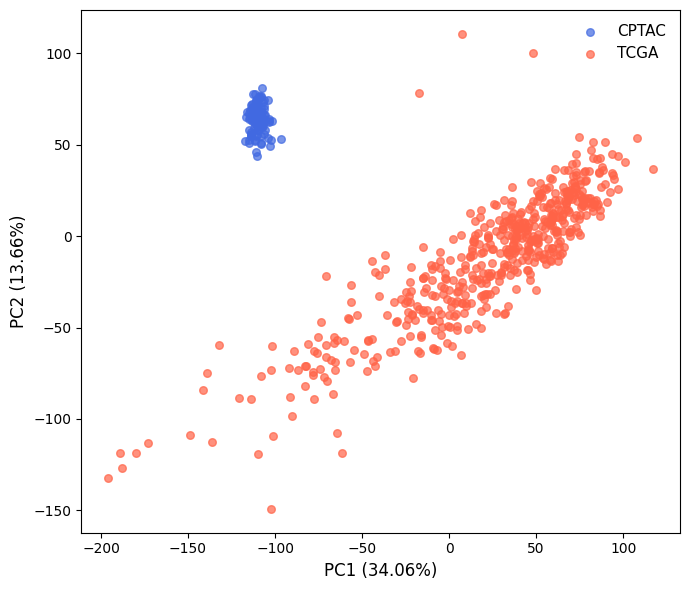

In [42]:
# =====================================================
# ComBat
# Part 3
# PCA Before ComBat
# =====================================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# =====================================================
# Combine datasets
# Samples × Genes
# =====================================================

combined_before = pd.concat(

    [

        expr_cptac.T,

        expr_tcga_matrix.T

    ],

    axis=0

)

batch = (

    ["CPTAC"] * expr_cptac.shape[1]

    +

    ["TCGA"] * expr_tcga_matrix.shape[1]

)

print()

print("="*60)
print("Combined Matrix Before ComBat")
print("="*60)

print(combined_before.shape)

# =====================================================
# Standardization (for PCA only)
# =====================================================

scaler = StandardScaler()

combined_scaled = scaler.fit_transform(

    combined_before

)

# =====================================================
# PCA
# =====================================================

pca = PCA(

    n_components=2,

    random_state=42

)

pcs = pca.fit_transform(

    combined_scaled

)

plot_df = pd.DataFrame({

    "PC1": pcs[:,0],

    "PC2": pcs[:,1],

    "Batch": batch

})

print()

print("="*60)
print("Explained Variance Before ComBat")
print("="*60)

print(

    "PC1:",

    round(

        pca.explained_variance_ratio_[0]*100,

        2

    ),

    "%"

)

print(

    "PC2:",

    round(

        pca.explained_variance_ratio_[1]*100,

        2

    ),

    "%"

)

print(

    "Total:",

    round(

        pca.explained_variance_ratio_.sum()*100,

        2

    ),

    "%"

)

# =====================================================
# PCA Plot
# =====================================================

plt.figure(figsize=(7,6))

colors = {

    "CPTAC":"royalblue",

    "TCGA":"tomato"

}

for b in colors:

    idx = plot_df["Batch"] == b

    plt.scatter(

        plot_df.loc[idx,"PC1"],

        plot_df.loc[idx,"PC2"],

        s=30,

        alpha=0.7,

        color=colors[b],

        label=b

    )

plt.xlabel(

    f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)",

    fontsize=12

)

plt.ylabel(

    f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)",

    fontsize=12

)


plt.legend(

    frameon=False,

    fontsize=11

)

plt.tight_layout()

plt.savefig(

    "PCA_Before_ComBat.png",

    dpi=600,

    bbox_inches="tight"

)

plt.show()

In [43]:
# =====================================================
# ComBat
# Part 4
# Batch Correction
# =====================================================

from combat.pycombat import pycombat

combined_matrix = pd.concat(

    [

        expr_cptac,

        expr_tcga_matrix

    ],

    axis=1

)

batch = pd.Series(

    ["CPTAC"]*expr_cptac.shape[1]

    +

    ["TCGA"]*expr_tcga_matrix.shape[1]

)

combat_matrix = pycombat(

    combined_matrix,

    batch

)

combat_cptac = combat_matrix.iloc[
    :,
    :expr_cptac.shape[1]
]

combat_tcga = combat_matrix.iloc[
    :,
    expr_cptac.shape[1]:
]

combat_cptac.to_csv(
    "RNA_ComBat_CPTAC.csv"
)

combat_tcga.to_csv(
    "RNA_ComBat_TCGA.csv"
)

print()

print("="*60)
print("ComBat Finished")
print("="*60)

print("ComBat CPTAC :", combat_cptac.shape)

print("ComBat TCGA  :", combat_tcga.shape)

Found 2 batches.
Adjusting for 0 covariate(s) or covariate level(s).
Standardizing Data across genes.
Fitting L/S model and finding priors.
Finding parametric adjustments.
Adjusting the Data

ComBat Finished
ComBat CPTAC : (13802, 103)
ComBat TCGA  : (13802, 525)


Explained Variance After ComBat
[0.3136191  0.07221761]

Total: 0.386


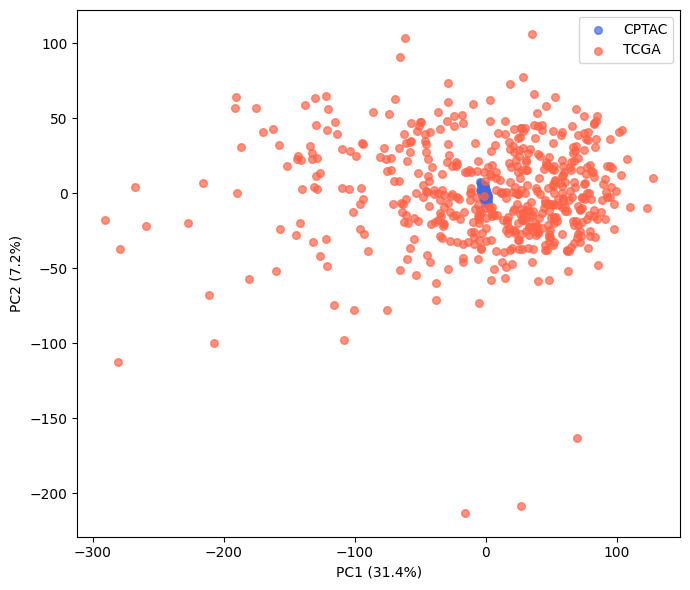

In [44]:
# =====================================================
# ComBat
# Part 5
# PCA After ComBat
# =====================================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# =====================================================
# Combine ComBat datasets
# =====================================================

combined_after = pd.concat(

    [

        combat_cptac.T,

        combat_tcga.T

    ],

    axis=0

)

batch = (

    ["CPTAC"] * combat_cptac.shape[1]

    +

    ["TCGA"] * combat_tcga.shape[1]

)

# =====================================================
# Standardization (PCA only)
# =====================================================

scaler = StandardScaler()

combined_scaled = scaler.fit_transform(

    combined_after

)

# =====================================================
# PCA
# =====================================================

pca = PCA(

    n_components=2

)

pcs = pca.fit_transform(

    combined_scaled

)

plot_df = pd.DataFrame({

    "PC1": pcs[:,0],

    "PC2": pcs[:,1],

    "Batch": batch

})

print("="*60)
print("Explained Variance After ComBat")
print("="*60)

print(pca.explained_variance_ratio_)

print()

print(

    "Total:",

    round(

        pca.explained_variance_ratio_.sum(),

        3

    )

)

# =====================================================
# Plot
# =====================================================

plt.figure(figsize=(7,6))

colors = {

    "CPTAC":"royalblue",

    "TCGA":"tomato"

}

for b in colors:

    idx = plot_df["Batch"] == b

    plt.scatter(

        plot_df.loc[idx,"PC1"],

        plot_df.loc[idx,"PC2"],

        s=30,

        alpha=0.7,

        color=colors[b],

        label=b

    )

plt.xlabel(

    f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)"

)

plt.ylabel(

    f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)"

)



plt.legend()

plt.tight_layout()

plt.savefig(

    "PCA_After_ComBat.png",

    dpi=600,

    bbox_inches="tight"

)

plt.show()

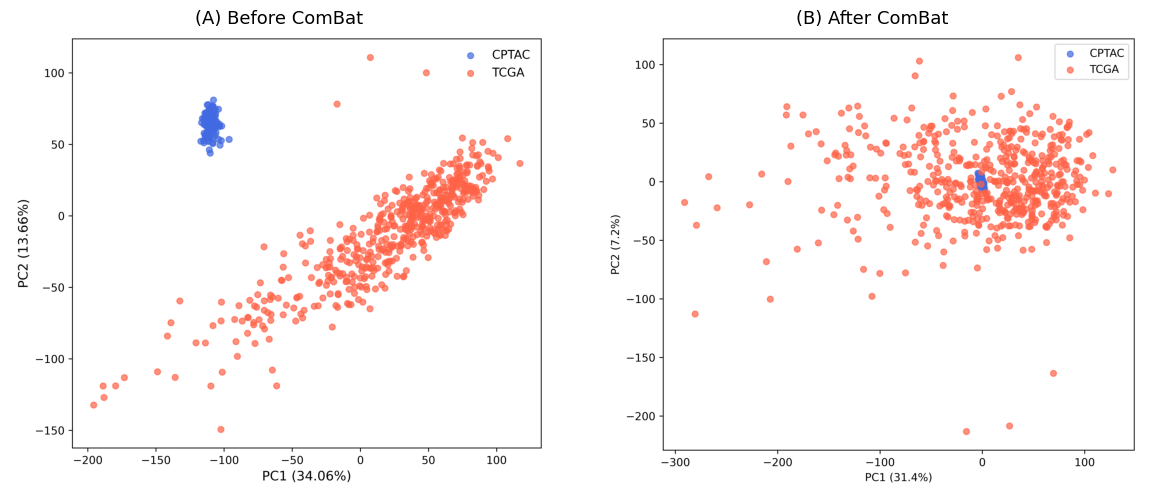

In [45]:
# =====================================================
# Merge Before & After ComBat PCA
# =====================================================

from PIL import Image
import matplotlib.pyplot as plt

# Read images
img_before = Image.open("PCA_Before_ComBat.png")
img_after = Image.open("PCA_After_ComBat.png")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# (A)
axes[0].imshow(img_before)
axes[0].axis("off")
axes[0].set_title("(A) Before ComBat", fontsize=13)

# (B)
axes[1].imshow(img_after)
axes[1].axis("off")
axes[1].set_title("(B) After ComBat", fontsize=13)

plt.tight_layout()

plt.savefig(
    "Figure_ComBat_PCA.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [46]:
# =====================================================
# RNA DEA (TRAIN SET ONLY)
# =====================================================

import pandas as pd
import numpy as np

from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

from sklearn.model_selection import train_test_split

# =====================================================
# Build labels
# =====================================================

sample_grade = clinical.set_index(
    "case_id"
)["grade_bin"]

# =====================================================
# Train / Test Split
# =====================================================

train_ids, test_ids = train_test_split(
    sample_grade.index,
    test_size=0.30,
    stratify=sample_grade,
    random_state=42
)

print("Train:", len(train_ids))
print("Test :", len(test_ids))

# =====================================================
# Clinical (Train only)
# =====================================================

train_clinical = clinical[
    clinical["case_id"].isin(train_ids)
]

low_samples = train_clinical.loc[
    train_clinical["grade_bin"] == "Low",
    "case_id"
]

high_samples = train_clinical.loc[
    train_clinical["grade_bin"] == "High",
    "case_id"
]

print("Low grade:", len(low_samples))
print("High grade:", len(high_samples))

# =====================================================
# Expression matrix (ComBat corrected)
# =====================================================

expr = combat_cptac.copy()

expr_low = expr[low_samples]

expr_high = expr[high_samples]

# =====================================================
# DEA
# =====================================================

results = []

for gene in expr.index:

    low_values = expr_low.loc[gene]
    high_values = expr_high.loc[gene]

    log2FC = (
        high_values.mean()
        -
        low_values.mean()
    )

    stat, pvalue = ttest_ind(
        high_values,
        low_values,
        equal_var=False
    )

    results.append([
        gene,
        log2FC,
        pvalue
    ])

# =====================================================
# DEA table
# =====================================================

dea = pd.DataFrame(
    results,
    columns=[
        "Gene",
        "log2FC",
        "P.Value"
    ]
)

# =====================================================
# FDR
# =====================================================

dea["adj.P.Val"] = multipletests(
    dea["P.Value"],
    method="fdr_bh"
)[1]

dea = dea.sort_values(
    "adj.P.Val"
)

# =====================================================
# Save
# =====================================================

dea.to_csv(
    "RNA_DEA_TrainOnly_ComBat.csv",
    index=False
)

# =====================================================
# Statistics
# =====================================================

sig = dea[
    dea["adj.P.Val"] < 0.05
]

sig_fc = dea[
    (dea["adj.P.Val"] < 0.05)
    &
    (abs(dea["log2FC"]) > 1)
]

print("Genes tested:", len(dea))
print("FDR < 0.05:", len(sig))
print("|log2FC| > 1:", len(sig_fc))

Train: 72
Test : 31
Low grade: 38
High grade: 34
Genes tested: 13802
FDR < 0.05: 334
|log2FC| > 1: 0


Status
Not Significant    13468
Downregulated        221
Upregulated          113
Name: count, dtype: int64

Most Downregulated Genes
         Gene    log2FC  adj.P.Val
287   ADORA2A -0.318297   0.038483
1777    CCL14 -0.254112   0.032725

Most Upregulated Genes
        Gene    log2FC  adj.P.Val
5390  IL20RB  0.316420   0.042831
9578    RGS1  0.260686   0.018338


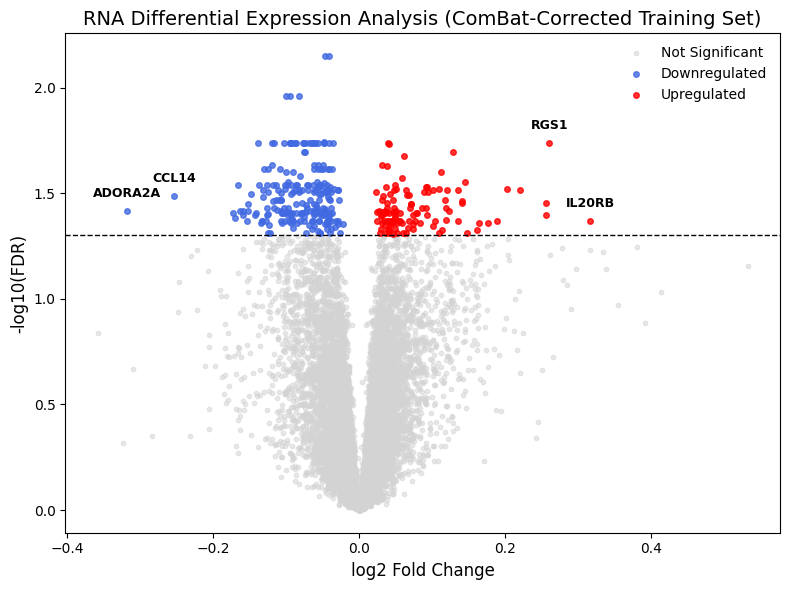

In [47]:
# =====================================================
# RNA Volcano Plot
# ComBat-Corrected Training Set
# =====================================================

import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# -log10(FDR)
# =====================================================

dea["minus_log10_FDR"] = -np.log10(
    dea["adj.P.Val"]
)

# =====================================================
# Classification
# =====================================================

dea["Status"] = "Not Significant"

dea.loc[
    (dea["adj.P.Val"] < 0.05) &
    (dea["log2FC"] > 0),
    "Status"
] = "Upregulated"

dea.loc[
    (dea["adj.P.Val"] < 0.05) &
    (dea["log2FC"] < 0),
    "Status"
] = "Downregulated"

# =====================================================
# Counts
# =====================================================

print(dea["Status"].value_counts())

# =====================================================
# Plot
# =====================================================

plt.figure(figsize=(8,6))

# -----------------------------------------------------
# Not Significant
# -----------------------------------------------------

plt.scatter(

    dea.loc[
        dea["Status"]=="Not Significant",
        "log2FC"
    ],

    dea.loc[
        dea["Status"]=="Not Significant",
        "minus_log10_FDR"
    ],

    color="lightgrey",

    s=10,

    alpha=0.5,

    label="Not Significant"

)

# -----------------------------------------------------
# Downregulated
# -----------------------------------------------------

plt.scatter(

    dea.loc[
        dea["Status"]=="Downregulated",
        "log2FC"
    ],

    dea.loc[
        dea["Status"]=="Downregulated",
        "minus_log10_FDR"
    ],

    color="royalblue",

    s=16,

    alpha=0.8,

    label="Downregulated"

)

# -----------------------------------------------------
# Upregulated
# -----------------------------------------------------

plt.scatter(

    dea.loc[
        dea["Status"]=="Upregulated",
        "log2FC"
    ],

    dea.loc[
        dea["Status"]=="Upregulated",
        "minus_log10_FDR"
    ],

    color="red",

    s=16,

    alpha=0.8,

    label="Upregulated"

)

# =====================================================
# FDR threshold
# =====================================================

plt.axhline(

    y=-np.log10(0.05),

    color="black",

    linestyle="--",

    linewidth=1

)


# =====================================================
# Label genes
# Left 2 + Right 2
# =====================================================

left2 = (

    dea

    .loc[
        dea["Status"] == "Downregulated"
    ]

    .sort_values(
        "log2FC"
    )

    .head(2)

)

right2 = (

    dea

    .loc[
        dea["Status"] == "Upregulated"
    ]

    .sort_values(
        "log2FC",
        ascending=False
    )

    .head(2)

)

top_genes = pd.concat([

    left2,

    right2

])

print("\nMost Downregulated Genes")

print(

    left2[
        [
            "Gene",
            "log2FC",
            "adj.P.Val"
        ]
    ]

)

print("\nMost Upregulated Genes")

print(

    right2[
        [
            "Gene",
            "log2FC",
            "adj.P.Val"
        ]
    ]

)


for _, row in top_genes.iterrows():

    plt.annotate(

        row["Gene"],

        (
            row["log2FC"],
            row["minus_log10_FDR"]
        ),

        xytext=(0, 8),

        textcoords="offset points",

        fontsize=9,

        fontweight="bold",

        ha="center",

        va="bottom"

    )

# =====================================================
# Labels
# =====================================================

plt.xlabel(

    "log2 Fold Change",

    fontsize=12

)

plt.ylabel(

    "-log10(FDR)",

    fontsize=12

)

plt.title(

    "RNA Differential Expression Analysis (ComBat-Corrected Training Set)",

    fontsize=14

)

plt.legend(

    frameon=False,

    loc="upper right"

)

plt.tight_layout()

# =====================================================
# Save
# =====================================================

plt.savefig(

    "RNA_Volcano_TrainOnly_ComBat.png",

    dpi=600,

    bbox_inches="tight"

)

plt.show()

Top 30 DEGs:
['ATXN3', 'TECPR2', 'PPP1R13B', 'KLHDC1', 'RUNX1T1', 'LIPE', 'DCAF5', 'MED6', 'ARID4A', 'ATG2B', 'HID1', 'ARHGEF15', 'BTBD7', 'SOX18', 'GPHN', 'C8orf58', 'EXD2', 'WDR20', 'SNCAIP', 'PTPN21', 'TRIL', 'SHE', 'GTF2H3', 'CEP68', 'ZNF582', 'ZNF583', 'ZNF839', 'HSPA12B', 'TRIB2', 'RGS1']
(30, 72)


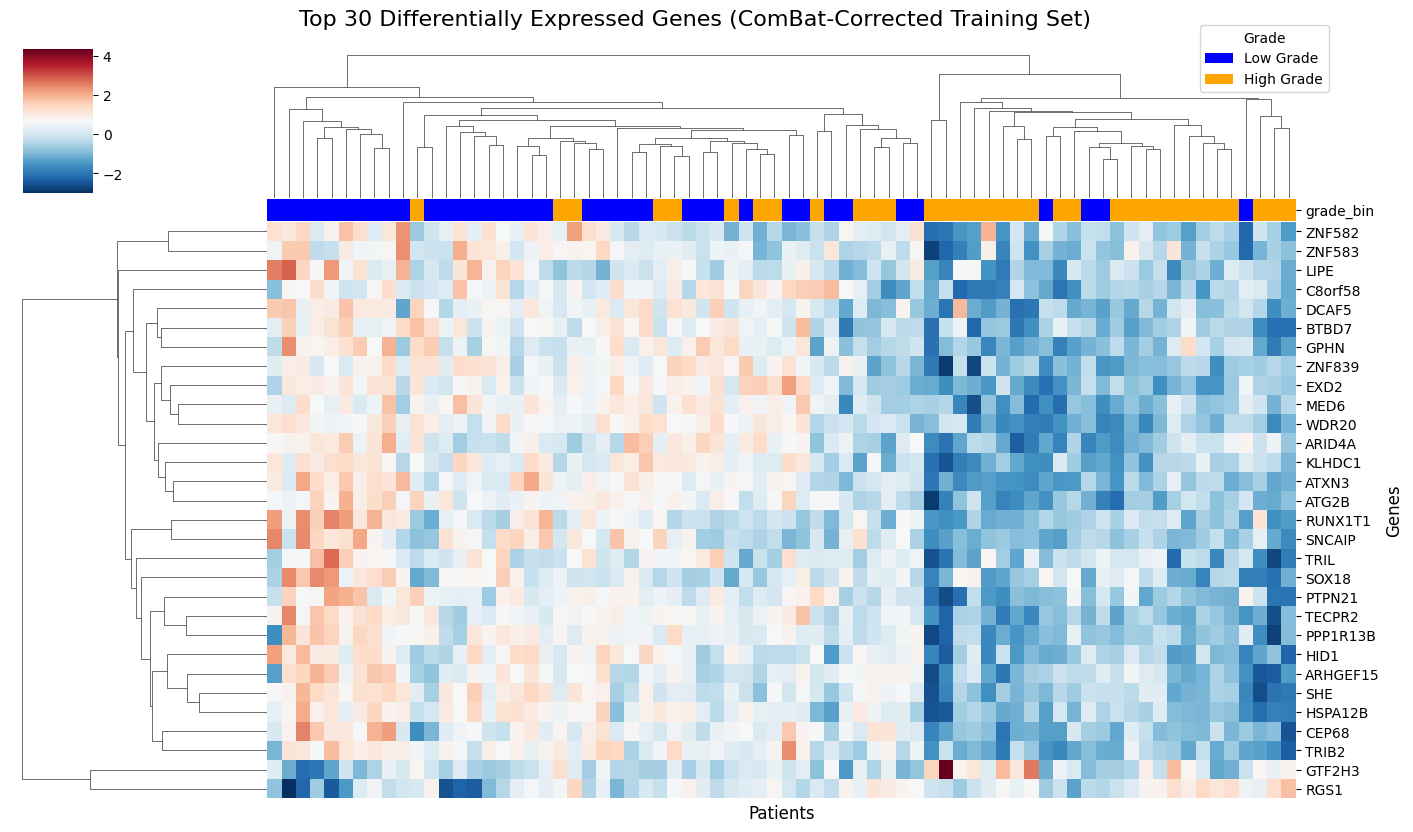

In [48]:
# =====================================================
# Heatmap
# All Significant DEGs
# Genes = rows
# Samples = columns
# =====================================================

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# =====================================================
# Top 30 DEGs
# =====================================================

top30_genes = (
    dea
    .sort_values("adj.P.Val")
    .head(30)["Gene"]
)

print("Top 30 DEGs:")
print(top30_genes.tolist())

# =====================================================
# Expression matrix
# =====================================================

expr = combat_cptac.copy()

heatmap_data = expr.loc[
    top30_genes,
    train_ids
]

print(
    heatmap_data.shape
)

# =====================================================
# Grade annotation
# =====================================================

sample_grade = clinical.set_index(
    "case_id"
).loc[
    train_ids,
    "grade_bin"
]

col_colors = sample_grade.map({
    "Low": "blue",
    "High": "orange"
})

# =====================================================
# Heatmap
# =====================================================

g = sns.clustermap(

    heatmap_data,

    z_score=0,          # gene-wise scaling

    cmap="RdBu_r",

    row_cluster=True,
    col_cluster=True,

    col_colors=col_colors,

    figsize=(14,8),

    xticklabels=False,

    yticklabels=True
)

# =====================================================
# Legend
# =====================================================
g.ax_heatmap.set_xlabel(
    "Patients",
    fontsize=12
)

g.ax_heatmap.set_ylabel(
    "Genes", 
    fontsize=12
)


g.ax_heatmap.set_xlabel(
    "Patients",
    fontsize=12
)

g.ax_heatmap.set_ylabel(
    "Genes", 
    fontsize=12
)


handles = [

    Patch(
        facecolor="blue",
        label="Low Grade"
    ),

    Patch(
        facecolor="orange",
        label="High Grade"
    )
]

g.ax_col_dendrogram.legend(
    handles=handles,
    title="Grade",
    bbox_to_anchor=(0.9, 1.2),
    loc="upper left"
)

# =====================================================
# Title
# =====================================================

g.fig.suptitle(
    "Top 30 Differentially Expressed Genes (ComBat-Corrected Training Set)",
    fontsize=16,
    y=1.03
)



# =====================================================
# Save
# =====================================================

g.savefig(
    "RNA_DEG_Heatmap_TrainOnly_ComBat.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [49]:
# =====================================================
# Variance Filter after DEA
# Train Set Only
# =====================================================

# DEA genes
deg_genes = dea.loc[
    dea["adj.P.Val"] < 0.05,
    "Gene"
]

print(
    "\nDEA genes:",
    len(deg_genes)
)

# =====================================================
# Expression matrix (ComBat corrected)
# genes × train samples
# =====================================================

expr = combat_cptac.copy()

dea_expr = expr.loc[
    deg_genes,
    train_ids
]

print(
    "DEA matrix:",
    dea_expr.shape
)

# =====================================================
# Variance calculation
# =====================================================

gene_var = dea_expr.var(
    axis=1
)

print("\nVariance summary")

print(
    gene_var.describe()
)

print("\nVariance quantiles")

print(
    gene_var.quantile(
        [0.25, 0.5, 0.75, 0.9]
    )
)

# =====================================================
# Keep Top 25% variance genes
# =====================================================

cutoff = gene_var.quantile(
    0.75
)

selected_genes = gene_var[
    gene_var > cutoff
].index

print(
    "\nGenes after variance filtering:",
    len(selected_genes)
)

# =====================================================
# Filter DEA table
# =====================================================

dea_var = dea[
    dea["Gene"].isin(
        selected_genes
    )
].copy()

dea_var = dea_var.sort_values(
    "adj.P.Val"
)

print(
    "\nRemaining genes:",
    len(dea_var)
)

# =====================================================
# Save
# =====================================================

dea_var.to_csv(
    "RNA_DEA_VarianceFiltered_ComBat.csv",
    index=False
)

print(
    "\nSaved: RNA_DEA_VarianceFiltered_ComBat.csv"
)


DEA genes: 334
DEA matrix: (334, 72)

Variance summary
count    334.000000
mean       0.012476
std        0.018276
min        0.000790
25%        0.003145
50%        0.006522
75%        0.015073
max        0.161256
dtype: float64

Variance quantiles
0.25    0.003145
0.50    0.006522
0.75    0.015073
0.90    0.026658
dtype: float64

Genes after variance filtering: 84

Remaining genes: 84

Saved: RNA_DEA_VarianceFiltered_ComBat.csv


In [50]:
# =====================================================
# Model 1
# LASSO Feature Selection
# DEA -> Variance Filter -> LASSO
# =====================================================

import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import (
    LogisticRegressionCV,
    LogisticRegression
)

# =====================================================
# Variance-filtered genes
# =====================================================

deg_genes = dea_var["Gene"].tolist()

print(
    "Variance-filtered genes:",
    len(deg_genes)
)

# =====================================================
# Expression matrix (ComBat corrected)
# =====================================================

expr = combat_cptac.copy()

X = (
    expr.loc[
        deg_genes,
        train_ids
    ]
    .T
)

print(
    "X shape:",
    X.shape
)

# =====================================================
# Labels
# =====================================================

y = (
    clinical
    .set_index("case_id")
    .loc[
        train_ids,
        "grade_bin"
    ]
    .map({
        "Low":0,
        "High":1
    })
)

print("\nClass distribution")

print(
    y.value_counts()
)

# =====================================================
# Pipeline
# =====================================================

pipe = Pipeline([

    (
        "scaler",
        StandardScaler()
    ),

    (
        "lasso",
        LogisticRegressionCV(

            penalty="l1",

            solver="saga",

            cv=5,

            scoring="roc_auc",

            max_iter=10000,

            random_state=42,

            n_jobs=-1

        )
    )
])

# =====================================================
# Fit
# =====================================================

pipe.fit(
    X,
    y
)

lasso_cv = pipe.named_steps["lasso"]

print("\nBest C")

print(
    lasso_cv.C_[0]
)

# =====================================================
# CV Results
# =====================================================

scores = lasso_cv.scores_[1]

mean_auc = scores.mean(axis=0)

std_auc = scores.std(axis=0)

auc_table = pd.DataFrame({

    "C": lasso_cv.Cs_,

    "Mean_AUC": mean_auc,

    "Std_AUC": std_auc

})

print("\nCV Results")

print(
    auc_table
)

# =====================================================
# Final LASSO
# =====================================================

best_C = lasso_cv.C_[0]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

lasso = LogisticRegression(

    penalty="l1",

    solver="saga",

    C=best_C,

    max_iter=10000,

    random_state=42

)

lasso.fit(
    X_scaled,
    y
)

# =====================================================
# Selected genes
# =====================================================

coef = pd.Series(

    lasso.coef_[0],

    index=X.columns

)

selected_genes = coef[
    coef != 0
]

selected_genes = (

    selected_genes

    .sort_values(
        key=np.abs,
        ascending=False
    )

)

print(
    "\nSelected genes:",
    len(selected_genes)
)

print(
    "\nTop selected genes"
)

print(
    selected_genes.head(20)
)

# =====================================================
# Save
# =====================================================

selected_genes.to_csv(
    "RNA_LASSO_Selected_Genes_ComBat.csv"
)

print(
    "\nSaved: RNA_LASSO_Selected_Genes_ComBat.csv"
)

# =====================================================
# Summary
# =====================================================

summary = pd.DataFrame({

    "Metric":[

        "Input Genes",

        "Selected Genes",

        "Best C"

    ],

    "Value":[

        len(deg_genes),

        len(selected_genes),

        best_C

    ]
})

print("\nLASSO Summary")

print(summary)

summary.to_csv(
    "LASSO_Summary_ComBat.csv",
    index=False
)

Variance-filtered genes: 84
X shape: (72, 84)

Class distribution
grade_bin
0    38
1    34
Name: count, dtype: int64

Best C
0.3593813663804626

CV Results
              C  Mean_AUC   Std_AUC
0      0.000100  0.500000  0.000000
1      0.000774  0.500000  0.000000
2      0.005995  0.500000  0.000000
3      0.046416  0.500000  0.000000
4      0.359381  0.848214  0.122279
5      2.782559  0.812925  0.098022
6     21.544347  0.800680  0.090185
7    166.810054  0.788946  0.090034
8   1291.549665  0.788946  0.090034
9  10000.000000  0.788946  0.090034

Selected genes: 14

Top selected genes
CLEC4E      0.639225
KIAA0319    0.471025
NCS1        0.395359
PKIB        0.356950
ADAM20     -0.319749
OVCH1      -0.282497
SYT13       0.241006
PLPP2       0.234825
RGS1        0.226091
RGS2        0.209678
CCL14      -0.206279
DNAJC12     0.169753
ADORA2A    -0.083214
GNLY       -0.034967
dtype: float64

Saved: RNA_LASSO_Selected_Genes_ComBat.csv

LASSO Summary
           Metric      Value
0     Inpu

In [51]:
# =====================================================
# LASSO Stability Analysis
# =====================================================

from sklearn.model_selection import StratifiedKFold
from collections import Counter

print("\n")
print("="*60)
print("LASSO STABILITY ANALYSIS (ComBat)")
print("="*60)

# -----------------------------------------------------
# CV
# -----------------------------------------------------

cv = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=42
)

# -----------------------------------------------------
# Counter
# -----------------------------------------------------

gene_counter = Counter()

fold_summary = []

# -----------------------------------------------------
# Loop
# -----------------------------------------------------

for fold_id, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):

    print(f"\nFold {fold_id}")

    X_fold = X.iloc[train_idx]

    y_fold = y.iloc[train_idx]

    # ---------------------------------------------
    # Standardize
    # ---------------------------------------------

    scaler_fold = StandardScaler()

    X_fold_scaled = scaler_fold.fit_transform(
        X_fold
    )

    # ---------------------------------------------
    # LASSO
    # ---------------------------------------------

    lasso_fold = LogisticRegression(

        penalty="l1",

        solver="saga",

        C=best_C,

        max_iter=10000,

        random_state=42
    )

    lasso_fold.fit(

        X_fold_scaled,

        y_fold
    )

    coef_fold = pd.Series(

        lasso_fold.coef_[0],

        index=X.columns
    )

    selected_fold = coef_fold[
        coef_fold != 0
    ].index.tolist()

    print(
        "Selected genes:",
        len(selected_fold)
    )

    gene_counter.update(
        selected_fold
    )

    fold_summary.append({

        "Fold":fold_id,

        "Selected_Genes":len(selected_fold)

    })

# -----------------------------------------------------
# Stability Table
# -----------------------------------------------------

stability = pd.DataFrame({

    "Gene":list(
        gene_counter.keys()
    ),

    "Frequency":list(
        gene_counter.values()
    )

})

stability["Selection_Rate"] = (

    stability["Frequency"]

    / 5

    * 100

)

stability = stability.sort_values(

    ["Frequency","Gene"],

    ascending=[False,True]

)

print("\n")
print("="*60)
print("GENE STABILITY")
print("="*60)

print(stability)

# -----------------------------------------------------
# Stable genes
# -----------------------------------------------------

stable_genes = stability[
    stability["Frequency"] >= 4
]

print("\n")
print("="*60)
print("HIGHLY STABLE GENES")
print("="*60)

print(stable_genes)

# -----------------------------------------------------
# Save
# -----------------------------------------------------

stability.to_csv(

    "LASSO_Gene_Stability_ComBat.csv",

    index=False
)

print(
    "\nSaved: LASSO_Gene_Stability_ComBat.csv"
)



LASSO STABILITY ANALYSIS (ComBat)

Fold 1
Selected genes: 17

Fold 2
Selected genes: 15

Fold 3
Selected genes: 16

Fold 4
Selected genes: 18

Fold 5
Selected genes: 14


GENE STABILITY
        Gene  Frequency  Selection_Rate
1     CLEC4E          5           100.0
3   KIAA0319          5           100.0
0       PKIB          5           100.0
12     SYT13          5           100.0
5     ADAM20          4            80.0
4      CCL14          4            80.0
9    DNAJC12          4            80.0
2      OVCH1          4            80.0
15      RGS2          4            80.0
14    MFSD2A          3            60.0
17     NBPF1          3            60.0
27      NCS1          3            60.0
7       APOH          2            40.0
10       ID1          2            40.0
28      NME1          2            40.0
25      PDPR          2            40.0
19     PLPP2          2            40.0
8      PRAME          2            40.0
23      RGS1          2            40.0
18    SEMA3G

Selected genes: 14
['CLEC4E', 'KIAA0319', 'NCS1', 'PKIB', 'ADAM20', 'OVCH1', 'SYT13', 'PLPP2', 'RGS1', 'RGS2', 'CCL14', 'DNAJC12', 'ADORA2A', 'GNLY']

Train shape: (72, 14)
Test shape: (31, 14)

Train Performance
AUC: 0.974
Accuracy: 0.931
Sensitivity: 0.912
Specificity: 0.947

Test Performance
AUC: 0.794
Accuracy: 0.710
Sensitivity: 0.786
Specificity: 0.647

Logistic Regression Results
              Metric   Value
0     Selected Genes  14.000
1          Train AUC   0.974
2     Train Accuracy   0.931
3  Train Sensitivity   0.912
4  Train Specificity   0.947
5           Test AUC   0.794
6      Test Accuracy   0.710
7   Test Sensitivity   0.786
8   Test Specificity   0.647

Gene Coefficients
        Gene  Coefficient
0     CLEC4E     1.058627
1   KIAA0319     0.736899
3       PKIB     0.725362
4     ADAM20    -0.620331
11   DNAJC12     0.571129
5      OVCH1    -0.558241
9       RGS2     0.547011
10     CCL14    -0.534754
2       NCS1     0.507719
6      SYT13     0.495864
8       RGS1   

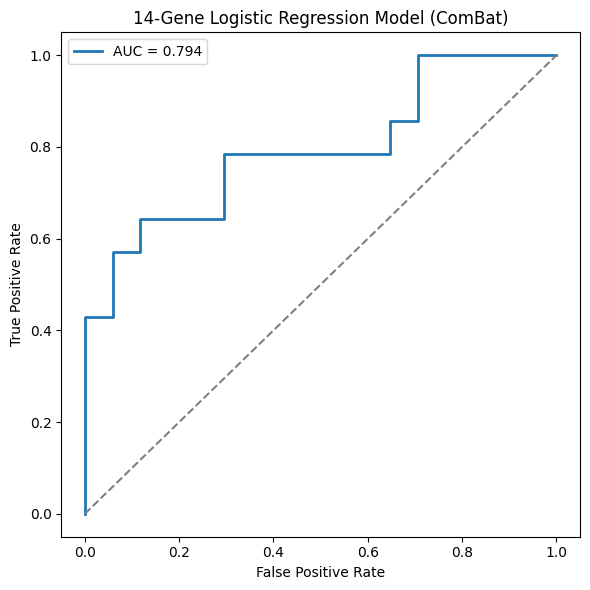


Saved:
Model1_Logistic_14Gene_Results_ComBat.csv
Model1_Logistic_14Gene_Coefficients_ComBat.csv
Model1_Logistic_14Gene_ROC_ComBat.png


In [52]:
# =====================================================
# Model 1
# Logistic Regression
# 14-Gene LASSO Signature (ComBat)
# =====================================================

import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (

    roc_auc_score,

    accuracy_score,

    confusion_matrix,

    roc_curve

)

import matplotlib.pyplot as plt

# =====================================================
# LASSO-selected genes
# =====================================================

lasso_genes = selected_genes.index.tolist()

print(
    "Selected genes:",
    len(lasso_genes)
)

print(
    lasso_genes
)

# =====================================================
# Expression matrix
# =====================================================

expr = combat_cptac.copy()

X_train = (

    expr.loc[
        lasso_genes,
        train_ids
    ]

    .T
)

X_test = (

    expr.loc[
        lasso_genes,
        test_ids
    ]

    .T
)

print(
    "\nTrain shape:",
    X_train.shape
)

print(
    "Test shape:",
    X_test.shape
)

# =====================================================
# Labels
# =====================================================

y_train = (

    clinical

    .set_index("case_id")

    .loc[
        train_ids,
        "grade_bin"
    ]

    .map({
        "Low":0,
        "High":1
    })
)

y_test = (

    clinical

    .set_index("case_id")

    .loc[
        test_ids,
        "grade_bin"
    ]

    .map({
        "Low":0,
        "High":1
    })
)

# =====================================================
# Logistic Regression Pipeline
# =====================================================

pipe = Pipeline([

    (

        "scaler",

        StandardScaler()

    ),

    (

        "lr",

        LogisticRegression(

            penalty="l2",

            C=1,

            max_iter=10000,

            random_state=42

        )

    )

])

# =====================================================
# Train Final Model
# =====================================================

pipe.fit(

    X_train,

    y_train

)

# =====================================================
# Train Prediction
# =====================================================

train_prob = pipe.predict_proba(

    X_train

)[:,1]

train_pred = (

    train_prob >= 0.5

).astype(int)

# =====================================================
# Train Performance
# =====================================================

train_auc = roc_auc_score(

    y_train,

    train_prob

)

train_acc = accuracy_score(

    y_train,

    train_pred

)

tn, fp, fn, tp = confusion_matrix(

    y_train,

    train_pred

).ravel()

train_sens = tp / (tp + fn)

train_spec = tn / (tn + fp)

print("\n==========================")

print("Train Performance")

print("==========================")

print(
    f"AUC: {train_auc:.3f}"
)

print(
    f"Accuracy: {train_acc:.3f}"
)

print(
    f"Sensitivity: {train_sens:.3f}"
)

print(
    f"Specificity: {train_spec:.3f}"
)

# =====================================================
# Test Prediction
# =====================================================

test_prob = pipe.predict_proba(

    X_test

)[:,1]

test_pred = (

    test_prob >= 0.5

).astype(int)

# =====================================================
# Test Performance
# =====================================================

test_auc = roc_auc_score(

    y_test,

    test_prob

)

test_acc = accuracy_score(

    y_test,

    test_pred

)

tn, fp, fn, tp = confusion_matrix(

    y_test,

    test_pred

).ravel()

test_sens = tp / (tp + fn)

test_spec = tn / (tn + fp)

print("\n==========================")

print("Test Performance")

print("==========================")

print(
    f"AUC: {test_auc:.3f}"
)

print(
    f"Accuracy: {test_acc:.3f}"
)

print(
    f"Sensitivity: {test_sens:.3f}"
)

print(
    f"Specificity: {test_spec:.3f}"
)


# =====================================================
# Results Table
# =====================================================

results = pd.DataFrame({

    "Metric":[

        "Selected Genes",

        "Train AUC",

        "Train Accuracy",

        "Train Sensitivity",

        "Train Specificity",

        "Test AUC",

        "Test Accuracy",

        "Test Sensitivity",

        "Test Specificity"

    ],

    "Value":[

        len(lasso_genes),

        train_auc,

        train_acc,

        train_sens,

        train_spec,

        test_auc,

        test_acc,

        test_sens,

        test_spec

    ]

})

results = results.round(3)

print("\n==========================")

print("Logistic Regression Results")

print("==========================")

print(results)

results.to_csv(

    "Model1_Logistic_14Gene_Results_ComBat.csv",

    index=False

)

# =====================================================
# Gene Coefficients
# =====================================================

coef = pd.DataFrame({

    "Gene": lasso_genes,

    "Coefficient": pipe.named_steps["lr"].coef_[0]

})

coef = coef.sort_values(

    "Coefficient",

    key=np.abs,

    ascending=False

)

print("\n==========================")

print("Gene Coefficients")

print("==========================")

print(coef)

coef.to_csv(

    "Model1_Logistic_14Gene_Coefficients_ComBat.csv",

    index=False

)

# =====================================================
# ROC Curve
# =====================================================

fpr, tpr, _ = roc_curve(

    y_test,

    test_prob

)

plt.figure(figsize=(6,6))

plt.plot(

    fpr,

    tpr,

    linewidth=2,

    label=f"AUC = {test_auc:.3f}"

)

plt.plot(

    [0,1],

    [0,1],

    linestyle="--",

    color="grey"

)

plt.xlabel(

    "False Positive Rate"

)

plt.ylabel(

    "True Positive Rate"

)

plt.title(

    "14-Gene Logistic Regression Model (ComBat)"

)

plt.legend()

plt.tight_layout()

plt.savefig(

    "Model1_Logistic_14Gene_ROC_ComBat.png",

    dpi=600,

    bbox_inches="tight"

)

plt.show()

# =====================================================
# Summary
# =====================================================

print("\nSaved:")

print(

    "Model1_Logistic_14Gene_Results_ComBat.csv"

)

print(

    "Model1_Logistic_14Gene_Coefficients_ComBat.csv"

)

print(

    "Model1_Logistic_14Gene_ROC_ComBat.png"

)


Genes: 84

Best Parameters
{'max_depth': 4, 'min_samples_leaf': 3, 'n_estimators': 200}

Best CV AUC: 0.85

CV AUCs
[0.821 0.857 0.694 0.918 0.958]

Mean CV AUC: 0.85
Std CV AUC: 0.091

Train Performance
AUC: 1.000
Accuracy: 0.986
Sensitivity: 1.000
Specificity: 0.974

Test Performance
AUC: 0.845
Accuracy: 0.742
Sensitivity: 0.714
Specificity: 0.765

Top 20 Genes
        Gene  Importance
0       RGS1    0.053268
8     CLEC4E    0.042165
3       RCN1    0.034448
32      APOH    0.030377
14  KIAA0319    0.028574
51   SLCO2A1    0.026690
60      MAPT    0.026618
10     NBPF1    0.023240
34   COL22A1    0.021694
57     SYT13    0.020800
33     PRAME    0.019843
6      ADCY4    0.018998
20    PSMD14    0.018661
36   DNAJC12    0.018289
18     PLPP2    0.018098
2        SHE    0.017676
5   RALGAPA1    0.017653
68       ID3    0.017514
40   EXOC3L2    0.016480
41     RAMP3    0.016374

RF84 Results (ComBat)
               Metric   Value
0               Genes  84.000
1         Best CV AUC   0.

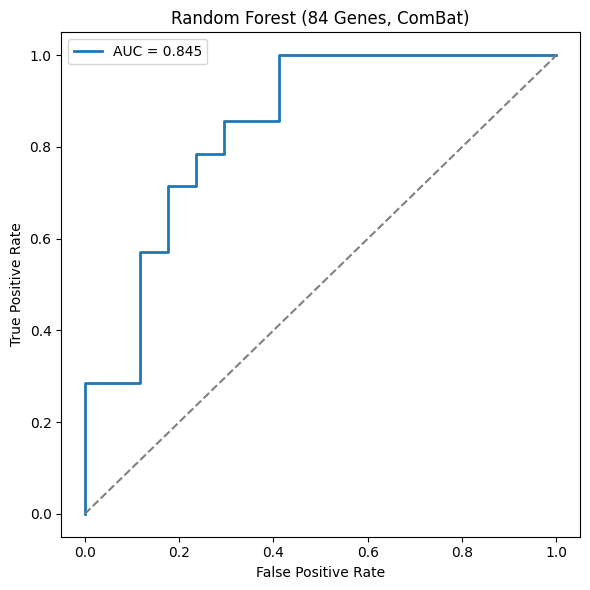


Saved:
RF84_FeatureImportance_ComBat.csv
RF84_Results_ComBat.csv
RF84_ROC_ComBat.png


In [53]:
# =====================================================
# Model 2A
# Random Forest
# 84 Variance-filtered Genes (ComBat)
# =====================================================

import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import (
    StratifiedKFold,
    GridSearchCV,
    cross_val_score
)

from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    confusion_matrix,
    roc_curve
)

import matplotlib.pyplot as plt

# =====================================================
# 84 genes
# =====================================================

rf_genes = dea_var["Gene"].tolist()

print(
    "Genes:",
    len(rf_genes)
)

# =====================================================
# Expression matrix
# =====================================================

expr = combat_cptac.copy()

X_train = expr.loc[
    rf_genes,
    train_ids
].T

X_test = expr.loc[
    rf_genes,
    test_ids
].T

# =====================================================
# Labels
# =====================================================

y_train = (
    clinical
    .set_index("case_id")
    .loc[
        train_ids,
        "grade_bin"
    ]
    .map({
        "Low":0,
        "High":1
    })
)

y_test = (
    clinical
    .set_index("case_id")
    .loc[
        test_ids,
        "grade_bin"
    ]
    .map({
        "Low":0,
        "High":1
    })
)

# =====================================================
# Grid Search
# =====================================================

param_grid = {

    "n_estimators":[100,200],

    "max_depth":[2,3,4,5],

    "min_samples_leaf":[3,5,7]

}

cv = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=42

)

grid = GridSearchCV(

    RandomForestClassifier(

        class_weight="balanced",

        random_state=42

    ),

    param_grid,

    cv=cv,

    scoring="roc_auc",

    n_jobs=-1

)

grid.fit(
    X_train,
    y_train
)

rf = grid.best_estimator_

print("\nBest Parameters")

print(
    grid.best_params_
)

print(
    "\nBest CV AUC:",
    round(grid.best_score_,3)
)

# =====================================================
# Cross Validation
# =====================================================

cv_auc = cross_val_score(

    rf,

    X_train,

    y_train,

    cv=cv,

    scoring="roc_auc",

    n_jobs=-1

)

print("\nCV AUCs")

print(
    np.round(cv_auc,3)
)

print(
    "\nMean CV AUC:",
    round(cv_auc.mean(),3)
)

print(
    "Std CV AUC:",
    round(cv_auc.std(),3)
)

# =====================================================
# Train Final Model
# =====================================================

rf.fit(
    X_train,
    y_train
)

# =====================================================
# Train Prediction
# =====================================================

train_prob = rf.predict_proba(
    X_train
)[:,1]

train_pred = (
    train_prob >= 0.5
).astype(int)

# =====================================================
# Train Performance
# =====================================================

train_auc = roc_auc_score(
    y_train,
    train_prob
)

train_acc = accuracy_score(
    y_train,
    train_pred
)

tn, fp, fn, tp = confusion_matrix(
    y_train,
    train_pred
).ravel()

train_sens = tp / (tp + fn)

train_spec = tn / (tn + fp)

print("\n==========================")
print("Train Performance")
print("==========================")

print(
    f"AUC: {train_auc:.3f}"
)

print(
    f"Accuracy: {train_acc:.3f}"
)

print(
    f"Sensitivity: {train_sens:.3f}"
)

print(
    f"Specificity: {train_spec:.3f}"
)

# =====================================================
# Test Prediction
# =====================================================

test_prob = rf.predict_proba(
    X_test
)[:,1]

test_pred = (
    test_prob >= 0.5
).astype(int)

# =====================================================
# Test Performance
# =====================================================

test_auc = roc_auc_score(
    y_test,
    test_prob
)

test_acc = accuracy_score(
    y_test,
    test_pred
)

tn, fp, fn, tp = confusion_matrix(
    y_test,
    test_pred
).ravel()

test_sens = tp / (tp + fn)

test_spec = tn / (tn + fp)

print("\n==========================")
print("Test Performance")
print("==========================")

print(
    f"AUC: {test_auc:.3f}"
)

print(
    f"Accuracy: {test_acc:.3f}"
)

print(
    f"Sensitivity: {test_sens:.3f}"
)

print(
    f"Specificity: {test_spec:.3f}"
)

# =====================================================
# Feature Importance
# =====================================================

importance = pd.DataFrame({

    "Gene": X_train.columns,

    "Importance": rf.feature_importances_

})

importance = importance.sort_values(

    "Importance",

    ascending=False

)

print("\nTop 20 Genes")

print(

    importance.head(20)

)

importance.to_csv(

    "RF84_FeatureImportance_ComBat.csv",

    index=False

)

# =====================================================
# Results Table
# =====================================================

results = pd.DataFrame({

    "Metric":[

        "Genes",

        "Best CV AUC",

        "Mean CV AUC",

        "Std CV AUC",

        "Train AUC",

        "Train Accuracy",

        "Train Sensitivity",

        "Train Specificity",

        "Test AUC",

        "Test Accuracy",

        "Test Sensitivity",

        "Test Specificity"

    ],

    "Value":[

        len(rf_genes),

        grid.best_score_,

        cv_auc.mean(),

        cv_auc.std(),

        train_auc,

        train_acc,

        train_sens,

        train_spec,

        test_auc,

        test_acc,

        test_sens,

        test_spec

    ]

})

results = results.round(3)

print("\n==========================")

print("RF84 Results (ComBat)")

print("==========================")

print(results)

results.to_csv(

    "RF84_Results_ComBat.csv",

    index=False

)

# =====================================================
# ROC Curve
# =====================================================

fpr, tpr, _ = roc_curve(

    y_test,

    test_prob

)

plt.figure(figsize=(6,6))

plt.plot(

    fpr,

    tpr,

    linewidth=2,

    label=f"AUC = {test_auc:.3f}"

)

plt.plot(

    [0,1],

    [0,1],

    linestyle="--",

    color="grey"

)

plt.xlabel(

    "False Positive Rate"

)

plt.ylabel(

    "True Positive Rate"

)

plt.title(

    "Random Forest (84 Genes, ComBat)"

)

plt.legend()

plt.tight_layout()

plt.savefig(

    "RF84_ROC_ComBat.png",

    dpi=600,

    bbox_inches="tight"

)

plt.show()

# =====================================================
# Save
# =====================================================

print("\nSaved:")

print(

    "RF84_FeatureImportance_ComBat.csv"

)

print(

    "RF84_Results_ComBat.csv"

)

print(

    "RF84_ROC_ComBat.png"

)


RF84 Top20 Genes (ComBat)
        Gene  Importance
0       RGS1    0.053268
1     CLEC4E    0.042165
2       RCN1    0.034448
3       APOH    0.030377
4   KIAA0319    0.028574
5    SLCO2A1    0.026690
6       MAPT    0.026618
7      NBPF1    0.023240
8    COL22A1    0.021694
9      SYT13    0.020800
10     PRAME    0.019843
11     ADCY4    0.018998
12    PSMD14    0.018661
13   DNAJC12    0.018289
14     PLPP2    0.018098
15       SHE    0.017676
16  RALGAPA1    0.017653
17       ID3    0.017514
18   EXOC3L2    0.016480
19     RAMP3    0.016374


TOP 5

Genes
['RGS1', 'CLEC4E', 'RCN1', 'APOH', 'KIAA0319']

Train shape: (72, 5)
Test shape: (31, 5)

Mean CV AUC: 0.845
Std CV AUC: 0.067
Train AUC: 0.985
Test AUC: 0.773


TOP 10

Genes
['RGS1', 'CLEC4E', 'RCN1', 'APOH', 'KIAA0319', 'SLCO2A1', 'MAPT', 'NBPF1', 'COL22A1', 'SYT13']

Train shape: (72, 10)
Test shape: (31, 10)

Mean CV AUC: 0.92
Std CV AUC: 0.041
Train AUC: 0.998
Test AUC: 0.84


TOP 15

Genes
['RGS1', 'CLEC4E', 'RCN1', 'APOH'

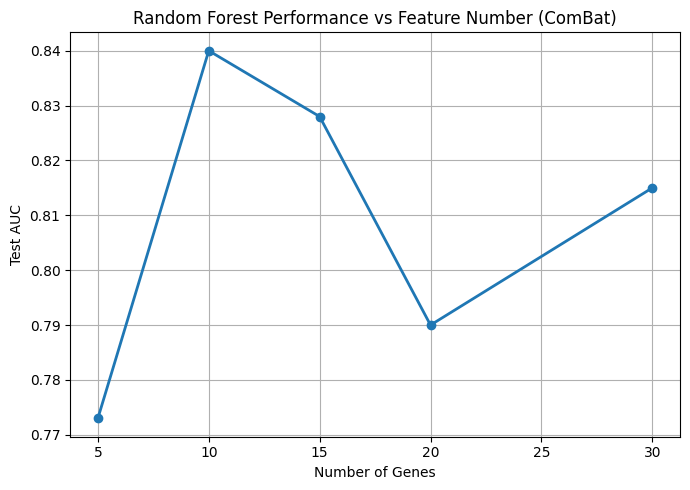


Best Feature Number
Genes          10.000
Mean CV AUC     0.920
Std CV AUC      0.041
Train AUC       0.998
Test AUC        0.840
Accuracy        0.742
Sensitivity     0.786
Specificity     0.706
Name: 1, dtype: float64

Saved:
RF_TopN_FixedRF_ComBat.csv
RF_TopN_Performance_ComBat.png


In [54]:
# =====================================================
# Model 2B
# RF Importance Signature
# Top5 / Top10 / Top15 / Top20 / Top30
# ComBat Corrected
# =====================================================

import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score
)

from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    confusion_matrix
)

import matplotlib.pyplot as plt

# =====================================================
# Load RF84 importance
# =====================================================

importance_rf84 = pd.read_csv(
    "RF84_FeatureImportance_ComBat.csv"
)

print(
    "\nRF84 Top20 Genes (ComBat)"
)

print(
    importance_rf84.head(20)
)


# =====================================================
# CV
# =====================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# =====================================================
# Fixed RF
# =====================================================

rf_fixed = RandomForestClassifier(

    n_estimators=200,

    max_depth=4,

    min_samples_leaf=3,

    class_weight="balanced",

    random_state=42
)

# =====================================================
# Result container
# =====================================================

all_results = []

# =====================================================
# Compare TopN
# =====================================================

for n_genes in [5,10,15,20,30]:

    print("\n")
    print("="*70)
    print(f"TOP {n_genes}")
    print("="*70)

    # -----------------------------------------
    # Top genes
    # -----------------------------------------

    top_genes = (
        importance_rf84
        .head(n_genes)["Gene"]
        .tolist()
    )

    print("\nGenes")

    print(top_genes)

    # -----------------------------------------
    # Matrix
    # -----------------------------------------

    expr = combat_cptac.copy()

    X_train_top = (

        expr.loc[
            top_genes,
            train_ids
        ]

        .T
    )

    X_test_top = (

        expr.loc[
            top_genes,
            test_ids
        ]

        .T
    )

    print(
        "\nTrain shape:",
        X_train_top.shape
    )

    print(
        "Test shape:",
        X_test_top.shape
    )

    # -----------------------------------------
    # CV
    # -----------------------------------------

    cv_auc = cross_val_score(

        rf_fixed,

        X_train_top,

        y_train,

        cv=cv,

        scoring="roc_auc",

        n_jobs=-1
    )

    print(
        "\nMean CV AUC:",
        round(cv_auc.mean(),3)
    )

    print(
        "Std CV AUC:",
        round(cv_auc.std(),3)
    )

    # -----------------------------------------
    # Train
    # -----------------------------------------

    rf_fixed.fit(
        X_train_top,
        y_train
    )

    train_prob = rf_fixed.predict_proba(
        X_train_top
    )[:,1]

    train_auc = roc_auc_score(
        y_train,
        train_prob
    )

    # -----------------------------------------
    # Test
    # -----------------------------------------

    test_prob = rf_fixed.predict_proba(
        X_test_top
    )[:,1]

    test_pred = (
        test_prob >= 0.5
    ).astype(int)

    test_auc = roc_auc_score(
        y_test,
        test_prob
    )

    test_acc = accuracy_score(
        y_test,
        test_pred
    )

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        test_pred
    ).ravel()

    test_sens = tp / (tp + fn)

    test_spec = tn / (tn + fp)

    print(
        "Train AUC:",
        round(train_auc,3)
    )

    print(
        "Test AUC:",
        round(test_auc,3)
    )

    # -----------------------------------------
    # Save
    # -----------------------------------------

    all_results.append([

        n_genes,

        cv_auc.mean(),

        cv_auc.std(),

        train_auc,

        test_auc,

        test_acc,

        test_sens,

        test_spec
    ])

# =====================================================
# Summary
# =====================================================

comparison = pd.DataFrame(

    all_results,

    columns=[

        "Genes",

        "Mean CV AUC",

        "Std CV AUC",

        "Train AUC",

        "Test AUC",

        "Accuracy",

        "Sensitivity",

        "Specificity"
    ]
)

comparison = comparison.round(3)

print("\n")
print("="*80)
print("RF TOP-N COMPARISON")
print("="*80)

print(comparison)

comparison.to_csv(
    "RF_TopN_FixedRF_ComBat.csv",
    index=False
)

# =====================================================
# Plot
# =====================================================

plt.figure(figsize=(7,5))

plt.plot(

    comparison["Genes"],

    comparison["Test AUC"],

    marker="o",

    linewidth=2
)

plt.xlabel(
    "Number of Genes"
)

plt.ylabel(
    "Test AUC"
)

plt.title(
    "Random Forest Performance vs Feature Number (ComBat)"
)

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "RF_TopN_Performance_ComBat.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# =====================================================
# Best Feature Number
# =====================================================

best_row = comparison.loc[
    comparison["Test AUC"].idxmax()
]

print("\nBest Feature Number")

print(best_row)

print("\nSaved:")
print("RF_TopN_FixedRF_ComBat.csv")
print("RF_TopN_Performance_ComBat.png")

In [55]:
import joblib

In [56]:
# =====================================================
# Model 2B
# RF Importance Signature
# Top10 Genes (ComBat)
# =====================================================

import pandas as pd

from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score
)

from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    confusion_matrix
)

# =====================================================
# Load RF86 importance
# =====================================================

importance_rf84 = pd.read_csv(
    "RF84_FeatureImportance_ComBat.csv"
)

print(
    "\nTop 20 RF84 Genes (ComBat)"
)

print(
    importance_rf84.head(20)
)

# =====================================================
# Top10 genes
# =====================================================

top10_genes = (

    importance_rf84

    .head(10)["Gene"]

    .tolist()
)

print(
    "\nTop10 Genes"
)

print(
    top10_genes
)

# =====================================================
# Build matrix
# =====================================================

expr = combat_cptac.copy()

X_train_top10 = (

    expr.loc[
        top10_genes,
        train_ids
    ]
    .T
)

X_test_top10 = (

    expr.loc[
        top10_genes,
        test_ids
    ]
    .T
)

print(
    "\nTrain shape:",
    X_train_top10.shape
)

print(
    "Test shape:",
    X_test_top10.shape
)

# =====================================================
# Labels
# =====================================================

y_train = (

    clinical

    .set_index("case_id")

    .loc[
        train_ids,
        "grade_bin"
    ]

    .map({
        "Low":0,
        "High":1
    })
)

y_test = (

    clinical

    .set_index("case_id")

    .loc[
        test_ids,
        "grade_bin"
    ]

    .map({
        "Low":0,
        "High":1
    })
)

# =====================================================
# CV
# =====================================================

cv = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=42
)

# =====================================================
# RF
# =====================================================

rf_top10 = RandomForestClassifier(

    n_estimators=200,

    max_depth=4,

    min_samples_leaf=3,

    class_weight="balanced",

    random_state=42
)

# =====================================================
# CV AUC
# =====================================================

cv_auc = cross_val_score(

    rf_top10,

    X_train_top10,

    y_train,

    cv=cv,

    scoring="roc_auc",

    n_jobs=-1
)

print(
    "\nMean CV AUC:",
    round(cv_auc.mean(),3)
)

print(
    "Std CV AUC:",
    round(cv_auc.std(),3)
)

# =====================================================
# Train
# =====================================================

rf_top10.fit(
    X_train_top10,
    y_train
)

train_prob = rf_top10.predict_proba(
    X_train_top10
)[:,1]

train_auc = roc_auc_score(
    y_train,
    train_prob
)

# =====================================================
# Test
# =====================================================

test_prob = rf_top10.predict_proba(
    X_test_top10
)[:,1]

test_pred = (
    test_prob >= 0.5
).astype(int)

test_auc = roc_auc_score(
    y_test,
    test_prob
)

test_acc = accuracy_score(
    y_test,
    test_pred
)

tn, fp, fn, tp = confusion_matrix(
    y_test,
    test_pred
).ravel()

test_sens = tp / (tp + fn)

test_spec = tn / (tn + fp)

# =====================================================
# Results
# =====================================================

results = pd.DataFrame({

    "Metric":[

        "Genes",

        "Mean CV AUC",

        "Std CV AUC",

        "Train AUC",

        "Test AUC",

        "Accuracy",

        "Sensitivity",

        "Specificity"

    ],

    "Value":[

        10,

        cv_auc.mean(),

        cv_auc.std(),

        train_auc,

        test_auc,

        test_acc,

        test_sens,

        test_spec

    ]
})

results = results.round(3)

print(
    "\nRF Top10 Results (ComBat)"
)

print(results)

results.to_csv(
    "RF_Top10_Results_ComBat.csv",
    index=False
)

print(
    "\nSaved: RF_Top10_Results_ComBat.csv"
)

# =====================================================
# Save Final Model
# =====================================================

joblib.dump(
    rf_top10,
    "RF_Top10_FinalModel_ComBat.pkl"
)

print(
    "\nFinal model saved:"
)

print(
    "RF_Top10_FinalModel_ComBat.pkl"
)


Top 20 RF84 Genes (ComBat)
        Gene  Importance
0       RGS1    0.053268
1     CLEC4E    0.042165
2       RCN1    0.034448
3       APOH    0.030377
4   KIAA0319    0.028574
5    SLCO2A1    0.026690
6       MAPT    0.026618
7      NBPF1    0.023240
8    COL22A1    0.021694
9      SYT13    0.020800
10     PRAME    0.019843
11     ADCY4    0.018998
12    PSMD14    0.018661
13   DNAJC12    0.018289
14     PLPP2    0.018098
15       SHE    0.017676
16  RALGAPA1    0.017653
17       ID3    0.017514
18   EXOC3L2    0.016480
19     RAMP3    0.016374

Top10 Genes
['RGS1', 'CLEC4E', 'RCN1', 'APOH', 'KIAA0319', 'SLCO2A1', 'MAPT', 'NBPF1', 'COL22A1', 'SYT13']

Train shape: (72, 10)
Test shape: (31, 10)

Mean CV AUC: 0.92
Std CV AUC: 0.041

RF Top10 Results (ComBat)
        Metric   Value
0        Genes  10.000
1  Mean CV AUC   0.920
2   Std CV AUC   0.041
3    Train AUC   0.998
4     Test AUC   0.840
5     Accuracy   0.742
6  Sensitivity   0.786
7  Specificity   0.706

Saved: RF_Top10_Results

In [57]:
# =====================================================
# External Validation
# Part 1
# Load Final Signature
# =====================================================

import pandas as pd

print("="*60)
print("External Validation")
print("="*60)

# =====================================================
# Load RF Feature Importance
# =====================================================

importance_rf84 = pd.read_csv(
    "RF84_FeatureImportance_ComBat.csv"
)

# =====================================================
# Top10 genes
# =====================================================

top10_genes = (

    importance_rf84

    .head(10)["Gene"]

    .tolist()

)

print()

print("Top10 genes")

for i, g in enumerate(top10_genes,1):

    print(f"{i}. {g}")

print()

print("Number of genes:",len(top10_genes))

External Validation

Top10 genes
1. RGS1
2. CLEC4E
3. RCN1
4. APOH
5. KIAA0319
6. SLCO2A1
7. MAPT
8. NBPF1
9. COL22A1
10. SYT13

Number of genes: 10


In [58]:
# =====================================================
# External Validation
# Part 2
# Load ComBat TCGA Data
# =====================================================

print()

print("="*60)
print("Load ComBat TCGA")
print("="*60)

# =====================================================
# ComBat TCGA expression
# =====================================================

combat_tcga = pd.read_csv(
    "RNA_ComBat_TCGA.csv",
    index_col=0
)

# =====================================================
# TCGA clinical
# =====================================================

clinical_tcga = pd.read_csv(
    "TCGA(tumor)/tcga_kirc_grade_metadata.csv"
)

print()

print("ComBat TCGA:")

print(combat_tcga.shape)

print()

print("Clinical:")

print(clinical_tcga.shape)

# =====================================================
# Check sample order
# =====================================================

print()

print("First five samples")

print(combat_tcga.columns[:5].tolist())

print()

print(clinical_tcga["barcode"].head().tolist())


Load ComBat TCGA

ComBat TCGA:
(13802, 525)

Clinical:
(525, 19)

First five samples
['TCGA-3Z-A93Z-01A-11R-A37O-07', 'TCGA-6D-AA2E-01A-11R-A37O-07', 'TCGA-A3-3306-01A-01R-0864-07', 'TCGA-A3-3307-01A-01R-0864-07', 'TCGA-A3-3308-01A-02R-1325-07']

['TCGA-3Z-A93Z-01A-11R-A37O-07', 'TCGA-6D-AA2E-01A-11R-A37O-07', 'TCGA-A3-3306-01A-01R-0864-07', 'TCGA-A3-3307-01A-01R-0864-07', 'TCGA-A3-3308-01A-02R-1325-07']


In [59]:
# =====================================================
# External Validation
# Part 3
# Prepare TCGA Matrix
# =====================================================

print()

print("="*60)
print("Prepare TCGA Matrix")
print("="*60)

# =====================================================
# Check genes
# =====================================================

missing_genes = [

    g

    for g in top10_genes

    if g not in combat_tcga.index

]

print()

print("Missing genes:", len(missing_genes))

if len(missing_genes) > 0:

    print(missing_genes)

# =====================================================
# Expression matrix
# Samples × Genes
# =====================================================

X_tcga = (

    combat_tcga.loc[
        top10_genes,
        clinical_tcga["barcode"]
    ]

    .T

)

print()

print("TCGA matrix:")

print(X_tcga.shape)

# =====================================================
# Labels
# =====================================================

y_tcga = clinical_tcga["y_grade"]

print()

print("Grade distribution")

print(y_tcga.value_counts())

# =====================================================
# Final model
# =====================================================

rf_final = rf_top10

print()

print("Final model ready.")


Prepare TCGA Matrix

Missing genes: 0

TCGA matrix:
(525, 10)

Grade distribution
y_grade
1    282
0    243
Name: count, dtype: int64

Final model ready.


In [60]:
# =====================================================
# External Validation
# Part 4
# Prediction & Performance Evaluation
# =====================================================

from sklearn.metrics import (

    roc_auc_score,

    roc_curve,

    accuracy_score,

    precision_score,

    recall_score,

    f1_score,

    confusion_matrix,

    classification_report

)

# =====================================================
# Prediction
# =====================================================

tcga_prob = rf_final.predict_proba(

    X_tcga

)[:,1]

tcga_pred = rf_final.predict(

    X_tcga

)

# =====================================================
# Metrics
# =====================================================

auc = roc_auc_score(

    y_tcga,

    tcga_prob

)

acc = accuracy_score(

    y_tcga,

    tcga_pred

)

precision = precision_score(

    y_tcga,

    tcga_pred

)

recall = recall_score(

    y_tcga,

    tcga_pred

)

f1 = f1_score(

    y_tcga,

    tcga_pred

)

tn, fp, fn, tp = confusion_matrix(

    y_tcga,

    tcga_pred

).ravel()

specificity = tn / (tn + fp)

# =====================================================
# Results
# =====================================================

print()

print("="*60)
print("External Validation")
print("="*60)

print()

print("AUC :", round(auc,3))

print()

print(classification_report(

    y_tcga,

    tcga_pred,

    digits=3

))

print()

print("Accuracy    :", round(acc,3))

print("Precision   :", round(precision,3))

print("Sensitivity :", round(recall,3))

print("Specificity :", round(specificity,3))

print("F1-score    :", round(f1,3))


External Validation

AUC : 0.646

              precision    recall  f1-score   support

           0      0.550     0.798     0.651       243
           1      0.715     0.436     0.542       282

    accuracy                          0.604       525
   macro avg      0.632     0.617     0.596       525
weighted avg      0.638     0.604     0.592       525


Accuracy    : 0.604
Precision   : 0.715
Sensitivity : 0.436
Specificity : 0.798
F1-score    : 0.542


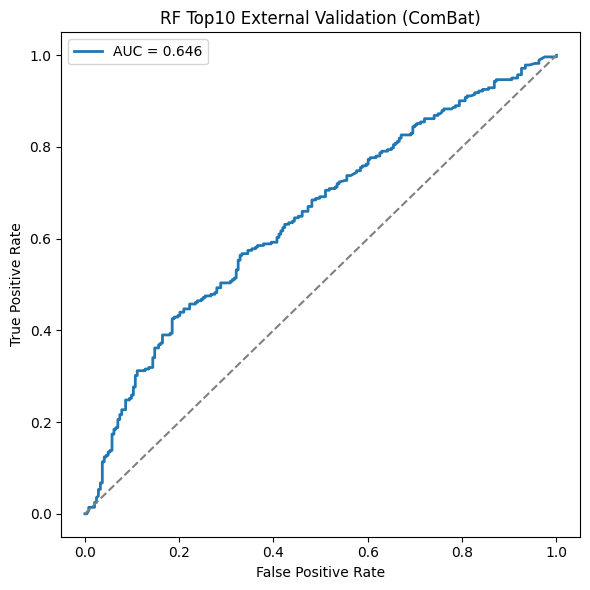

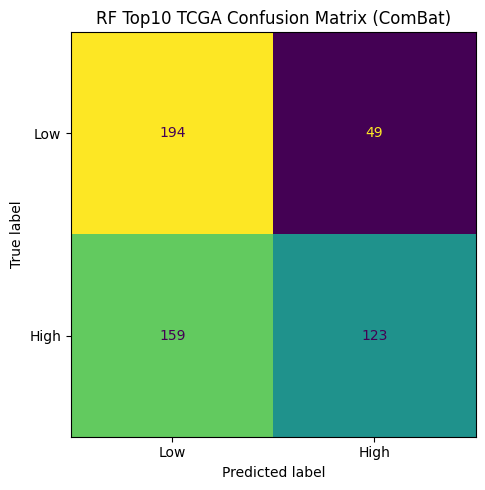


External Validation Results
        Metric  Value
0          AUC  0.646
1     Accuracy  0.604
2    Precision  0.715
3  Sensitivity  0.436
4  Specificity  0.798
5     F1-score  0.542

Saved
RF_Top10_TCGA_ROC_ComBat.png
RF_Top10_TCGA_ConfusionMatrix_ComBat.png
RF_Top10_TCGA_Prediction_ComBat.csv
RF_Top10_TCGA_ExternalValidation_ComBat.csv


In [61]:
# =====================================================
# External Validation
# Part 5
# ROC / Confusion Matrix / Save Results
# =====================================================

from sklearn.metrics import (
    roc_curve,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

# =====================================================
# ROC Curve
# =====================================================

fpr, tpr, _ = roc_curve(

    y_tcga,

    tcga_prob

)

plt.figure(figsize=(6,6))

plt.plot(

    fpr,

    tpr,

    linewidth=2,

    label=f"AUC = {auc:.3f}"

)

plt.plot(

    [0,1],

    [0,1],

    "--",

    color="grey"

)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("RF Top10 External Validation (ComBat)")

plt.legend()

plt.tight_layout()

plt.savefig(

    "RF_Top10_TCGA_ROC_ComBat.png",

    dpi=600,

    bbox_inches="tight"

)

plt.show()

# =====================================================
# Confusion Matrix
# =====================================================

cm = confusion_matrix(

    y_tcga,

    tcga_pred

)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=["Low","High"]

)

fig, ax = plt.subplots(figsize=(5,5))

disp.plot(

    ax=ax,

    colorbar=False

)

plt.title("RF Top10 TCGA Confusion Matrix (ComBat)")

plt.tight_layout()

plt.savefig(

    "RF_Top10_TCGA_ConfusionMatrix_ComBat.png",

    dpi=600,

    bbox_inches="tight"

)

plt.show()

# =====================================================
# Prediction File
# =====================================================

prediction = pd.DataFrame({

    "Sample": clinical_tcga["barcode"],

    "True": y_tcga,

    "Prediction": tcga_pred,

    "Probability": tcga_prob

})

prediction.to_csv(

    "RF_Top10_TCGA_Prediction_ComBat.csv",

    index=False

)

# =====================================================
# Save Results
# =====================================================

results = pd.DataFrame({

    "Metric":[

        "AUC",

        "Accuracy",

        "Precision",

        "Sensitivity",

        "Specificity",

        "F1-score"

    ],

    "Value":[

        auc,

        acc,

        precision,

        recall,

        specificity,

        f1

    ]

})

results = results.round(3)

results.to_csv(

    "RF_Top10_TCGA_ExternalValidation_ComBat.csv",

    index=False

)

print()

print("="*60)

print("External Validation Results")

print("="*60)

print(results)

print()

print("Saved")

print("RF_Top10_TCGA_ROC_ComBat.png")

print("RF_Top10_TCGA_ConfusionMatrix_ComBat.png")

print("RF_Top10_TCGA_Prediction_ComBat.csv")

print("RF_Top10_TCGA_ExternalValidation_ComBat.csv")